# CARLA 0.9.10 — Segmentation bám làn (bước 1/3)

Train Unet/ResNet34 phân đoạn 4 lớp `Background, Road, RoadLine, Sidewalk` từ ảnh RGB.
Checkpoint sinh ra là đầu vào của `train_il.ipynb` (bước 2) và `drl_training/` (bước 3).

Bảng nhãn là **hợp đồng dùng chung** với `data_collection/carla_collector/schema.py`
(`RAW_TO_TRAIN_LANE`) và `drl_training/policy/backbone.py` (`NUM_CLASSES`). Đổi ở đây thì
phải đổi đồng bộ cả ba nơi rồi train lại cả chuỗi.

Chia dữ liệu: Town01–04 train, Town05 val — domain shift thật, không phải chia ngẫu nhiên.

> **Bản vá cho hai sự cố đo được ở lần chạy trước.**
>
> **RAM tăng đều +2.9 GB/epoch, chết ở epoch 5.** `PERSISTENT_WORKERS` được trả về
> `False`: `_common` dùng chung cho cả hai loader nên `True` giữ 8 worker sống song song
> trên 4 vCPU, và worker không bao giờ chết cũng là worker không bao giờ reset RSS. Kèm
> theo: mask đi qua hàng đợi ở `uint8` thay vì `int64` (giảm 8 lần), `VAL_BATCH_SIZE`
> tách khỏi `BATCH_SIZE * 2`, và `mallopt(M_ARENA_MAX)` trong `seed_worker`.
>
> **42 phút/epoch → 40 epoch = 28 giờ, vượt xa giới hạn 12h của Kaggle.**
> `USE_CHANNELS_LAST` không còn bị tắt khi chạy 2 GPU (nguyên nhân `misaligned address`
> thật sự là bias lẻ trong SCSE, §8 đã vá) — trên T4 đây là điều kiện để cuDNN dùng
> tensor core fp16. Cộng `EMA_EVAL_START` bỏ lượt val-EMA ở 1/4 đầu, và
> `LAST_PATH`/`RESUME` để chia phần còn lại thành nhiều session.
>
> §9 giờ in thêm `ram: cha … | worker riêng …` và `wait …%` mỗi epoch — hai con số đó
> nói thẳng phần nào đang phình và liệu nút thắt có phải 4 vCPU hay không.

## 1. Import & cấu hình

In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("segmentation_models_pytorch") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "segmentation-models-pytorch"], check=True)
print("ok")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.2 MB/s eta 0:00:00
ok


In [2]:
import os, glob, random, time, gc, ctypes
from pathlib import Path

import cv2
cv2.setNumThreads(0)          # tránh tranh CPU với DataLoader worker
cv2.ocl.setUseOpenCL(False)

import numpy as np
import psutil
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm

torch.backends.cudnn.benchmark = True

print("torch", torch.__version__, "| albumentations", A.__version__, "| smp", smp.__version__)
print("CUDA", torch.cuda.is_available(), "| n_gpu", torch.cuda.device_count(),
      "| cpu", os.cpu_count())
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU{i}: {p.name}  {p.total_memory/1e9:.1f} GB")

torch 2.10.0+cu128 | albumentations 2.0.8 | smp 0.5.0
CUDA True | n_gpu 2 | cpu 4
  GPU0: Tesla T4  15.6 GB
  GPU1: Tesla T4  15.6 GB


In [3]:
SEED = 42

# --- Dữ liệu -----------------------------------------------------------------
# Thư mục chứa các folder Town0x_*. PHẢI giống hệt DATASET_ROOT của train_il.ipynb, nếu
# không hai model được train trên hai bản dữ liệu khác nhau.
DATASET_ROOT = "/kaggle/input/datasets/dlocg19/seg-il-dataset/CARLA_DATA"
TRAIN_TOWNS  = ["Town01", "Town02", "Town03", "Town04"]
VAL_TOWNS    = ["Town05"]
RGB_SUBDIR   = "rgb"
MASK_SUBDIR  = "seg_label"

WORK_DIR        = Path("/kaggle/working")
CACHE_DIR       = WORK_DIR / "cache"
CHECKPOINT_PATH = WORK_DIR / "best_carla_lane_seg.pth"
# Session Kaggle bị cắt cứng ở 12h. Ở ~42 phút/epoch thì 40 epoch = 28 giờ, tức KHÔNG
# THỂ chạy trong một session dù có sửa hết rò rỉ RAM. LAST_PATH được ghi mỗi epoch (kèm
# optimizer + scheduler + scaler + history) để lần chạy sau đặt RESUME=True là đi tiếp.
LAST_PATH       = WORK_DIR / "last_carla_lane_seg.pth"
RESUME          = False

# --- Kích thước ảnh ----------------------------------------------------------
IMAGE_HEIGHT = 384
IMAGE_WIDTH  = 480
assert IMAGE_HEIGHT % 32 == 0 and IMAGE_WIDTH % 32 == 0, "Unet cần hai cạnh chia hết cho 32"

# --- Kiến trúc (ghi vào checkpoint để phía IL dựng lại đúng) ------------------
MODEL_ARCH   = "unet"
ENCODER_NAME = "resnet34"
# Ghi vào checkpoint để IL/DRL dựng lại ĐÚNG kiến trúc: thiếu key này thì
# load_state_dict phía kia lệch key attention và fail.
DECODER_ATTENTION = "scse"      # "scse" | None

# --- Label scheme ------------------------------------------------------------
# "lane4": Background, Road, RoadLine, Sidewalk | "lane5": + Pedestrian
TASK_SCHEME       = "lane4"
RAILTRACK_AS_ROAD = True     # raw 16: ray tàu chìm trong mặt đường ở Town03 -> Road
SKY_AS_CLASS      = False    # False = trời gộp vào Background, VẪN được giám sát
IGNORE_UNLABELED  = False    # False = raw 0 -> Background, không phải 255
IGNORE_INDEX      = 255      # chỉ sinh ra từ fill_mask của A.Affine

# Class hiếm dưới ngưỡng pixel (ở train HOẶC val) sẽ bị gộp về Background — xem §3b.
AUTO_PRUNE           = True
MIN_CLASS_PIXEL_FRAC = 3e-4

# --- Optimization ------------------------------------------------------------
# Kaggle "GPU T4 x2": batch tổng được chia cho cả hai GPU ở §8 (DataParallel). BATCH_PER_GPU
# mới là thứ quyết định VRAM, BATCH_SIZE tổng suy ra từ nó — đổi số GPU không phải sửa tay.
# Đặt BATCH_PER_GPU = 8 nếu muốn giữ y hệt batch tổng = 16 của bản 1 GPU.
N_GPU           = torch.cuda.device_count()
# Công tắc thoát hiểm. DataParallel + decoder attention "scse" gây
# "CUDA error: misaligned address" (giải thích đầy đủ ở §8). §8 tự phát hiện và tự
# vá; đặt tay ALLOW_MULTI_GPU = False là đường lui chắc chắn nhất, đổi lại chậm ~1.8x.
ALLOW_MULTI_GPU = True
USE_MULTI_GPU   = N_GPU > 1 and ALLOW_MULTI_GPU
BATCH_PER_GPU = 16                  # ~2 GB activation/T4 ở 384x480 với AMP; 32 vẫn vừa
BATCH_SIZE    = BATCH_PER_GPU * max(N_GPU, 1)
EPOCHS        = 20

# LR scale theo CĂN BẬC HAI của tỉ lệ batch (AdamW): batch gấp đôi thì gradient noise chỉ
# giảm √2, scale tuyến tính sẽ quá mạnh cho lịch cosine ngắn 40 epoch.
BASE_LR, BASE_BATCH = 3e-4, 16
LEARNING_RATE       = BASE_LR * (BATCH_SIZE / BASE_BATCH) ** 0.5
WEIGHT_DECAY        = 1e-4
WARMUP_STEPS        = 500
MIN_LR_RATIO        = 0.02
GRAD_CLIP_NORM      = 1.0
# Giữ = EPOCHS/2. Lịch cosine dồn phần lớn cải thiện vào một phần ba cuối khi LR đã
# thấp; patience nhỏ sẽ cắt đúng lúc model sắp ăn điểm. Ở 20 epoch, patience 8 là quá chặt.
EARLY_STOP_PATIENCE = 10

DICE_WEIGHT        = 0.4
LABEL_SMOOTHING    = 0.02
WEIGHT_CLIP        = 4.0
CLASS_WEIGHT_BOOST = {"RoadLine": 1.6}   # class mỏng nhất nhưng quan trọng nhất

USE_EMA   = True
EMA_DECAY = 0.999
# Đánh giá EMA là MỘT LƯỢT VAL ĐẦY ĐỦ nữa mỗi epoch: 10k ảnh, ~1/3 chi phí val của epoch.
# Ở 1/4 đầu lịch cosine, trung bình trượt còn quá gần khởi tạo nên gần như không bao giờ
# thắng trọng số raw — bỏ qua nó ở giai đoạn đó là ~15% thời gian miễn phí.
EMA_EVAL_START = max(1, EPOCHS // 4)

# --- Runtime -----------------------------------------------------------------
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP           = torch.cuda.is_available()
# channels_last KHÔNG còn bị tắt khi chạy 2 GPU. Trước đây nó bị tắt kèm theo lỗi
# "misaligned address", nhưng nguyên nhân thật là bias lẻ phần tử trong SCSE (§8 vá rồi),
# không phải layout. Trên T4, kernel fp16 tensor-core của cuDNN chỉ đạt hiệu suất cao ở
# NHWC; chạy NCHW là phần lớn conv rơi về kernel không dùng tensor core — đây là ứng viên
# lớn nhất giải thích 42 phút/epoch. Probe ba giai đoạn ở §8 sẽ bắt được ngay nếu sai:
# nếu nó nổ, đặt cờ này = False rồi RESTART KERNEL (lỗi CUDA là sticky).
USE_CHANNELS_LAST = torch.cuda.is_available()

# Kaggle GPU session chỉ có 4 vCPU: 4 worker + process chính là vừa hết, thêm nữa thì các
# worker tranh CPU của nhau.
NUM_WORKERS        = min(os.cpu_count() or 2, 4)
PREFETCH_FACTOR    = 2
# ĐỪNG đặt True. `_common` được dùng cho CẢ train_loader lẫn val_loader, nên persistent
# giữ 4 worker của train sống trong khi 4 worker của val được tạo thêm: 8 tiến trình
# giành nhau 4 vCPU, và mỗi cái giữ nguyên hàng đợi prefetch của mình. Worker chết sau
# mỗi epoch cũng là thứ reset RSS của chúng — đo được +2.9 GB/epoch tuyến tính khi để
# True, chạm trần RAM ở epoch 5. Worker được tạo bằng fork nên chi phí spawn vốn đã nhỏ.
PERSISTENT_WORKERS = False
# Tách khỏi BATCH_SIZE * 2: batch val lớn chỉ tiết kiệm vài giây nhưng là dòng tốn RAM
# nhất trong hàng đợi (ảnh fp32 64x3x384x480 = 142 MB mỗi batch, nhân prefetch).
VAL_BATCH_SIZE     = BATCH_SIZE
JPEG_QUALITY       = 92

# 2 GPU tiêu thụ batch nhanh gấp đôi -> tiến trình chính bận collate/H2D hơn. Giới hạn
# thread BLAS của nó để không tranh 4 vCPU với DataLoader worker.
torch.set_num_threads(2)

# --- Bộ dữ liệu 5 FPS: 40k train (Town01-04) + 10k val (Town05) --------------
COLLECT_FPS = 5.0
CONTROL_DT  = 1.0 / COLLECT_FPS     # 0.2 s — hợp đồng bước thời gian với IL/DRL

# Lấy mẫu THƯA để một lịch 20 epoch chạy trọn trong một session 12h. `subsample_uniform`
# (§2) lấy các frame TRẢI ĐỀU chứ không cắt đầu/cuối, nên 20k frame vẫn phủ trọn lộ trình
# của cả Town01-04 — chỉ là ở FPS hiệu dụng 2.5 thay vì 5.
#
# Vì sao mất ít hơn con số "một nửa" gợi ý: dữ liệu thu ở 5 FPS nên hai frame liên tiếp
# cách nhau 200 ms và gần như trùng nhau về nội dung ảnh. Với một bài toán per-frame như
# segmentation, phần lớn cặp frame kề nhau là mẫu dư thừa; bỏ một nửa theo kiểu trải đều
# làm giảm số mẫu ĐỘC LẬP ít hơn nhiều so với 50%.
#
# Val 5000 frame Town05 = ~920 triệu pixel, thừa sức cho mIoU ổn định tới 3-4 chữ số.
# Đặt cả hai = None để chạy full khi có nhiều thời gian hơn.
TARGET_TRAIN = 5000
TARGET_VAL   = 1000
# GIỮ NGUYÊN 40000/10000: đây là kỳ vọng về dữ liệu GỐC trên đĩa, dùng để §2 phát hiện
# town thiếu/thừa file. Việc kiểm tra chạy TRƯỚC bước lấy mẫu thưa.
EXPECT_TRAIN, EXPECT_VAL = 40000, 10000

# --- Seeding -----------------------------------------------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def seed_worker(worker_id):
    # Thiếu hàm này thì mọi worker dùng chung một chuỗi RNG của random/numpy.
    s = torch.initial_seed() % 2**32
    np.random.seed(s)
    random.seed(s)
    # M_ARENA_MAX = -8. cv2.imdecode + albumentations cấp phát/giải phóng buffer kích
    # thước thay đổi hàng nghìn lần mỗi epoch; glibc giữ lại arena đã free thay vì trả
    # cho OS. mem_trim() gọi malloc_trim NHƯNG CHỈ trong tiến trình cha, worker không
    # bao giờ được trim. Giới hạn số arena là cách chặn phần phình đó ngay trong worker.
    try:
        ctypes.CDLL("libc.so.6").mallopt(-8, 2)
    except OSError:
        pass

LOADER_GEN = torch.Generator()
LOADER_GEN.manual_seed(SEED)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
_vm = psutil.virtual_memory()
print(f"{IMAGE_HEIGHT}x{IMAGE_WIDTH} | {MODEL_ARCH}/{ENCODER_NAME} "
      f"| scheme={TASK_SCHEME} | batch={BATCH_SIZE} | epochs={EPOCHS} "
      f"| amp={USE_AMP} | ema={USE_EMA}")
print(f"RAM tổng {_vm.total/1e9:.1f} GB | đang trống {_vm.available/1e9:.1f} GB "
      f"| vCPU {os.cpu_count()}")
print(f"{N_GPU} GPU | batch {BATCH_PER_GPU}/GPU x {max(N_GPU, 1)} = {BATCH_SIZE} "
      f"| lr {LEARNING_RATE:.2e} (= {BASE_LR:.0e} x √{BATCH_SIZE/BASE_BATCH:.0f}) "
      f"| workers {NUM_WORKERS}")
print(f"channels_last={USE_CHANNELS_LAST} | persistent_workers={PERSISTENT_WORKERS} "
      f"| val_batch={VAL_BATCH_SIZE} | ema_eval từ epoch {EMA_EVAL_START + 1} "
      f"| resume={RESUME}")


384x480 | unet/resnet34 | scheme=lane4 | batch=32 | epochs=20 | amp=True | ema=True
RAM tổng 33.7 GB | đang trống 31.8 GB | vCPU 4
2 GPU | batch 16/GPU x 2 = 32 | lr 4.24e-04 (= 3e-04 x √2) | workers 4
channels_last=True | persistent_workers=False | val_batch=32 | ema_eval từ epoch 6 | resume=False


## 2. Nạp dữ liệu & dò nhãn thật trong dataset

Ba câu hỏi phải trả lời trước khi train:

1. Mask lưu **class ID** (0–22) hay đã bị convert sang ảnh màu `CityScapesPalette`?
2. Dataset chứa những raw ID nào?
3. Tỉ lệ pixel từng raw ID — đầu vào cho bước prune ở §3b.

In [4]:
# 23 semantic tag của CARLA 0.9.10.
CARLA_0910_TAGS = {
    0: "Unlabeled",  1: "Building",    2: "Fence",       3: "Other",
    4: "Pedestrian", 5: "Pole",        6: "RoadLine",    7: "Road",
    8: "Sidewalk",   9: "Vegetation", 10: "Vehicles",   11: "Wall",
   12: "TrafficSign",
   13: "Sky",       14: "Ground",     15: "Bridge",     16: "RailTrack",
   17: "GuardRail", 18: "TrafficLight", 19: "Static",   20: "Dynamic",
   21: "Water",     22: "Terrain",
}
print(f"{len(CARLA_0910_TAGS)} tag tham chiếu.")

23 tag tham chiếu.


In [5]:
def check_dataset_root(root):
    """Xác nhận root do người dùng đặt là đúng chỗ, và in ra gợi ý nếu sai."""
    if not glob.glob(os.path.join(root, "Town01*")):
        raise FileNotFoundError(
            f"'{root}' không chứa folder 'Town01*'. Sửa DATASET_ROOT ở §1.\n"
            f"  Đang mount: {sorted(glob.glob('/kaggle/input/*'))}")
    print(f"DATASET_ROOT = {root}")


def read_mask_raw(path):
    # Collector ghi seg_label 1 kênh; nếu là ảnh 3 kênh thì tag nằm ở kênh đỏ (BGR -> 2).
    m = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if m is None:
        raise FileNotFoundError(f"Không đọc được mask: {path}")
    return np.ascontiguousarray(m[:, :, 2] if m.ndim == 3 else m)


def read_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def find_town_dirs(root, town):
    """TẤT CẢ folder khớp '{town}*' — một town thu nhiều phiên thì mọi phiên đều được dùng."""
    hits = sorted(h for h in glob.glob(os.path.join(root, f"{town}*")) if os.path.isdir(h))
    if not hits:
        raise FileNotFoundError(f"Không thấy folder '{town}*' trong {root}")
    return hits


def list_pairs(town_dir):
    """Ghép rgb/mask theo TÊN FILE (stem), không dựa vào thứ tự sorted() toàn cục."""
    rgb_dir, msk_dir = Path(town_dir) / RGB_SUBDIR, Path(town_dir) / MASK_SUBDIR
    if not rgb_dir.is_dir() or not msk_dir.is_dir():
        raise FileNotFoundError(f"{town_dir} thiếu '{RGB_SUBDIR}/' hoặc '{MASK_SUBDIR}/'")
    exts = (".png", ".jpg", ".jpeg")
    rgb_map = {p.stem: p for p in rgb_dir.iterdir() if p.suffix.lower() in exts}
    msk_map = {p.stem: p for p in msk_dir.iterdir() if p.suffix.lower() in exts}
    common = sorted(rgb_map.keys() & msk_map.keys())
    miss = len(rgb_map) + len(msk_map) - 2 * len(common)
    print(f"  {Path(town_dir).name:<28} {len(common):>6} cặp"
          + (f"   [{miss} file lẻ bị bỏ]" if miss else ""))
    return [(str(rgb_map[k]), str(msk_map[k])) for k in common]


def subsample_uniform(items, target, name=""):
    """Lấy `target` phần tử TRẢI ĐỀU: cắt đầu/cuối sẽ mất trọn từng đoạn của lộ trình."""
    n = len(items)
    if target is None or target >= n:
        return items
    idx = np.unique(np.linspace(0, n - 1, target).round().astype(int))
    print(f"  {name}: {n} -> {len(idx)}")
    return [items[i] for i in idx]


def collect_split(towns, target, name, expect):
    """Quét MỘT lượt thư mục: vừa gom cặp ảnh/mask, vừa đối chiếu số frame từng town.

    Tổng đúng vẫn có thể che một town thiếu + một town thừa, nên phải báo theo từng town.
    """
    per_town, pairs = {}, []
    print(f"{name} towns:")
    for t in towns:
        got = [p for d in find_town_dirs(DATASET_ROOT, t) for p in list_pairs(d)]
        per_town[t] = len(got)
        pairs += got
    exp_per = expect / len(towns)
    for t, n in per_town.items():
        flag = "   <-- lệch" if abs(n - exp_per) > 0.05 * exp_per else ""
        print(f"  {t}: {n} frame (kỳ vọng ~{exp_per:.0f}){flag}")
    if abs(len(pairs) - expect) > 0.02 * expect:
        print(f"  [!] {name}: {len(pairs)} frame, kỳ vọng ~{expect} "
              f"({100*(len(pairs)-expect)/expect:+.1f}%)")
    return subsample_uniform(pairs, target, name)


check_dataset_root(DATASET_ROOT)
train_pairs = collect_split(TRAIN_TOWNS, TARGET_TRAIN, "train", EXPECT_TRAIN)
val_pairs   = collect_split(VAL_TOWNS,   TARGET_VAL,   "val",   EXPECT_VAL)
assert train_pairs and val_pairs, "Dataset rỗng — kiểm tra lại DATASET_ROOT."

print(f"\nTổng: train={len(train_pairs)}  val={len(val_pairs)}")
if TARGET_TRAIN or TARGET_VAL:
    # Lấy mẫu trải đều KHÔNG rút ngắn quãng đường, chỉ làm nó thưa đi. Con số cần ghi vào
    # báo cáo là FPS hiệu dụng, không phải "số phút lái" (số phút không đổi).
    _eff = COLLECT_FPS * len(train_pairs) / EXPECT_TRAIN
    print(f"Lấy mẫu thưa: FPS hiệu dụng ≈ {_eff:.2f} (gốc {COLLECT_FPS:.0f}); vẫn phủ trọn "
          f"~{EXPECT_TRAIN/COLLECT_FPS/60:.0f} phút lái của {'+'.join(TRAIN_TOWNS)}.")
    print("COLLECT_FPS trong checkpoint VẪN là 5.0 — đó là tần số THU dữ liệu, hợp đồng "
          "bước thời gian với IL/DRL, không liên quan tới việc train seg dùng bao nhiêu frame.")
else:
    print(f"{len(train_pairs)/COLLECT_FPS/60:.0f} phút lái để train, "
          f"{len(val_pairs)/COLLECT_FPS/60:.0f} phút để val (ở {COLLECT_FPS:.0f} FPS).")

DATASET_ROOT = /kaggle/input/datasets/dlocg19/seg-il-dataset/CARLA_DATA
train towns:
  Town01_20260823_143945_281263  10000 cặp
  Town02_20260823_213146_563043   5000 cặp
  Town03_20260824_092246_845374  10000 cặp
  Town04_20260824_104201_022351  10000 cặp
  Town01: 10000 frame (kỳ vọng ~10000)
  Town02: 5000 frame (kỳ vọng ~10000)   <-- lệch
  Town03: 10000 frame (kỳ vọng ~10000)
  Town04: 10000 frame (kỳ vọng ~10000)
  [!] train: 35000 frame, kỳ vọng ~40000 (-12.5%)
  train: 35000 -> 5000
val towns:
  Town05_20260824_115020_218549   5000 cặp
  Town05: 5000 frame (kỳ vọng ~10000)   <-- lệch
  [!] val: 5000 frame, kỳ vọng ~10000 (-50.0%)
  val: 5000 -> 1000

Tổng: train=5000  val=1000
Lấy mẫu thưa: FPS hiệu dụng ≈ 0.62 (gốc 5); vẫn phủ trọn ~133 phút lái của Town01+Town02+Town03+Town04.
COLLECT_FPS trong checkpoint VẪN là 5.0 — đó là tần số THU dữ liệu, hợp đồng bước thời gian với IL/DRL, không liên quan tới việc train seg dùng bao nhiêu frame.


In [6]:
def probe_raw_labels(pairs, name, n=400, seed=0):
    """Histogram raw ID trên `n` mask lấy ngẫu nhiên."""
    sample = random.Random(seed).sample(pairs, min(n, len(pairs)))
    hist = np.zeros(256, dtype=np.int64)
    shapes, nch = set(), set()
    for _, mp in tqdm(sample, desc=f"probe {name}", leave=False):
        raw = cv2.imread(mp, cv2.IMREAD_UNCHANGED)
        nch.add(1 if raw.ndim == 2 else raw.shape[2])
        shapes.add(raw.shape[:2])
        hist += np.bincount((raw if raw.ndim == 2 else raw[:, :, 2]).ravel(), minlength=256)

    total, ids = hist.sum(), np.flatnonzero(hist)
    print(f"\n=== {name}  ({len(sample)} file) ===")
    print(f"  shape mask : {sorted(shapes)}   channels: {sorted(nch)}")
    print(f"  raw ID có mặt ({len(ids)}): {ids.tolist()}")
    if ids.max() > 28:
        print("  *** Kênh R có giá trị > 28: mask nhiều khả năng đã lưu bằng "
              "CityScapesPalette (ảnh MÀU). Phải sinh lại seg_label từ raw output. ***")

    print(f"\n  {'raw':>4} {'%pixel':>9}   {'CARLA 0.9.10':<14}")
    for i in ids:
        pct = 100 * hist[i] / total
        print(f"  {int(i):>4} {pct:>8.4f}%   {CARLA_0910_TAGS.get(int(i), '?'):<14}"
              + ("  <-- rất hiếm" if pct < 0.03 else ""))
    return hist


hist_train = probe_raw_labels(train_pairs, "TRAIN")
hist_val   = probe_raw_labels(val_pairs,   "VAL")

only_train = set(np.flatnonzero(hist_train).tolist()) - set(np.flatnonzero(hist_val).tolist())
only_val   = set(np.flatnonzero(hist_val).tolist())   - set(np.flatnonzero(hist_train).tolist())
if only_train: print(f"\n[!] raw ID chỉ có ở TRAIN: {sorted(only_train)}")
if only_val:   print(f"[!] raw ID chỉ có ở VAL: {sorted(only_val)}  <-- không thể học được")

probe TRAIN:   0%|          | 0/400 [00:00<?, ?it/s]


=== TRAIN  (400 file) ===
  shape mask : [(384, 480)]   channels: [1]
  raw ID có mặt (21): [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22]

   raw    %pixel   CARLA 0.9.10  
     0  28.3866%   Unlabeled     
     1   8.3130%   Building      
     2   0.4972%   Fence         
     3   0.0008%   Other           <-- rất hiếm
     5   0.8225%   Pole          
     6   1.6099%   RoadLine      
     7  37.6968%   Road          
     8   7.1481%   Sidewalk      
     9   7.8450%   Vegetation    
    10   0.0219%   Vehicles        <-- rất hiếm
    11   1.1069%   Wall          
    12   0.0140%   TrafficSign     <-- rất hiếm
    14   0.2160%   Ground        
    15   0.2705%   Bridge        
    16   0.4349%   RailTrack     
    17   0.4945%   GuardRail     
    18   0.0817%   TrafficLight  
    19   0.3229%   Static        
    20   0.1080%   Dynamic       
    21   0.0743%   Water         
    22   4.5344%   Terrain       


probe VAL:   0%|          | 0/400 [00:00<?, ?it/s]


=== VAL  (400 file) ===
  shape mask : [(384, 480)]   channels: [1]
  raw ID có mặt (20): [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 22]

   raw    %pixel   CARLA 0.9.10  
     0  28.3365%   Unlabeled     
     1  12.1823%   Building      
     2   0.5491%   Fence         
     3   0.0168%   Other           <-- rất hiếm
     5   0.8977%   Pole          
     6   3.3721%   RoadLine      
     7  42.3706%   Road          
     8   4.4655%   Sidewalk      
     9   2.3499%   Vegetation    
    10   0.0702%   Vehicles      
    11   0.3491%   Wall          
    12   0.0052%   TrafficSign     <-- rất hiếm
    14   0.1750%   Ground        
    15   0.0160%   Bridge          <-- rất hiếm
    16   0.0383%   RailTrack     
    17   0.5771%   GuardRail     
    18   0.3495%   TrafficLight  
    19   0.2277%   Static        
    20   0.0583%   Dynamic       
    22   3.5930%   Terrain       

[!] raw ID chỉ có ở TRAIN: [21]


## 3. Mapping raw → class nhiệm vụ

Mỗi class phải trả lời một câu hỏi mà bộ điều khiển thực sự đặt ra:

| Class | Câu hỏi | raw ID |
|-------|---------|--------|
| `Background` | Chỗ nào **không** đi được? | mọi raw còn lại, kể cả bầu trời (0/13) |
| `Road` | Tôi đi được ở đâu? | 7 (+16 RailTrack) |
| `RoadLine` | Làn của tôi nằm đâu? | 6 |
| `Sidewalk` | Mép đường phải giữ khoảng cách nằm đâu? | 8 |

Vì sao mọi thứ còn lại về `Background`:

- **Vehicle (10) / Pedestrian (4)**: dataset thu ở chế độ không NPC nên ~0% pixel. Class
  rỗng vẫn chiếm một kênh one-hot ở IL/DRL và kéo mIoU xuống với IoU ≈ 0. Bước tránh vật
  cản sẽ thu lại dữ liệu có NPC rồi thêm class trở lại.
- **Bầu trời (0/13)**: cùng câu trả lời "không đi được" như tường/cây. Đây **không phải**
  `ignore` — trời vẫn được giám sát đầy đủ, chỉ không chiếm một class riêng làm phồng mIoU.
- **Ground (14)**: CARLA định nghĩa Ground là mặt phẳng ngang *không phải* đường (bục,
  vòng xuyến, sân). Gán nó là Road tức là dạy model rằng lề bê tông cũng đi được.
- **Pole, TrafficSign, TrafficLight**: rộng 1–2 px ở 384×480, IoU trần ~0.05–0.15.
- **Building, Wall, Fence, Vegetation, Terrain, Bridge, GuardRail, Static, Dynamic, Water,
  Other**: model không cần phân biệt tường với hàng rào để bám làn.

In [7]:
_road_ids = [7] + ([16] if RAILTRACK_AS_ROAD else [])

# {tên class: [raw ID]}. Mọi raw ID không được liệt kê -> Background (0).
SCHEMES = {
    "lane4": [("Road", _road_ids), ("RoadLine", [6]), ("Sidewalk", [8])],
    "lane5": [("Road", _road_ids), ("RoadLine", [6]), ("Sidewalk", [8]), ("Pedestrian", [4])],
    # Bước tránh vật cản: thêm ("Vehicle", [10]) vào một scheme mới SAU khi đã thu lại dữ
    # liệu có NPC, rồi train lại đồng bộ cả IL lẫn DRL.
}
if TASK_SCHEME not in SCHEMES:
    raise ValueError(f"TASK_SCHEME phải thuộc {list(SCHEMES)}")

COLORS = {
    "Background": [ 60,  60,  60],
    "Road":       [128,  64, 128],
    "RoadLine":   [157, 234,  50],
    "Sidewalk":   [244,  35, 232],
    "Pedestrian": [220,  20,  60],
    "Sky":        [ 70, 130, 180],
    "Vehicle":    [  0,   0, 142],
}

# Class "mảnh" cần bảo tồn khi hạ độ phân giải (§5). RoadLine đứng sau nên ghi đè sau cùng.
THIN_RAW_IDS = [4, 6]


def build_label_space(groups):
    # Sky (nếu bật) luôn đứng CUỐI để các class trước giữ nguyên chỉ số: phía IL/DRL chỉ
    # cần đổi num_classes, không phải remap lại toàn bộ.
    groups = [g for g in groups if g[0] != "Sky"]
    if SKY_AS_CLASS:
        groups = groups + [("Sky", [0, 13])]
    names = ["Background"] + [g[0] for g in groups]
    lut = np.zeros(256, dtype=np.uint8)          # raw không liệt kê (kể cả > 22) -> 0
    raw2train = {r: 0 for r in CARLA_0910_TAGS}
    for gi, (nm, raws) in enumerate(groups, start=1):
        for r in raws:
            raw2train[r] = gi
            lut[r] = gi
    if IGNORE_UNLABELED and not SKY_AS_CLASS:
        lut[0] = IGNORE_INDEX
        raw2train[0] = IGNORE_INDEX
    return names, raw2train, lut, np.array([COLORS[n] for n in names], dtype=np.uint8)


GROUPS = list(SCHEMES[TASK_SCHEME])
CLASS_NAMES, RAW_TO_TRAIN, LABEL_LUT, PALETTE = build_label_space(GROUPS)
NUM_CLASSES = len(CLASS_NAMES)
BACKGROUND_ID = 0


def colorize(mask):
    out = np.zeros((*mask.shape, 3), np.uint8)
    valid = mask < NUM_CLASSES
    out[valid] = PALETTE[mask[valid]]
    return out


print(f"TASK_SCHEME = {TASK_SCHEME}  ->  {NUM_CLASSES} class")
for i, n in enumerate(CLASS_NAMES):
    print(f"  {i}  {n:<12} <- raw {[r for r, t in RAW_TO_TRAIN.items() if t == i]}")
print(f"\nignore_index = {IGNORE_INDEX} | SKY_AS_CLASS = {SKY_AS_CLASS} "
      f"| IGNORE_UNLABELED = {IGNORE_UNLABELED}")
if IGNORE_UNLABELED and not SKY_AS_CLASS:
    print("[!] raw 0 (bầu trời, ~26% pixel) đang bị ignore — 26% khung hình không có ràng "
          "buộc nào. Đặt IGNORE_UNLABELED=False.")
assert int(LABEL_LUT[10]) == BACKGROUND_ID, "raw 10 (Vehicles) phải về Background ở scheme này"

TASK_SCHEME = lane4  ->  4 class
  0  Background   <- raw [0, 1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22]
  1  Road         <- raw [7, 16]
  2  RoadLine     <- raw [6]
  3  Sidewalk     <- raw [8]

ignore_index = 255 | SKY_AS_CLASS = False | IGNORE_UNLABELED = False


### 3b. Tự động loại class quá hiếm

Bảng mapping ở trên là *ý định*, dataset mới là *thực tế*. Class nào có tỉ lệ pixel dưới
`MIN_CLASS_PIXEL_FRAC` ở **train hoặc val** sẽ bị gộp về Background: class chỉ có ở val thì
không thể học (IoU = 0 chắc chắn), class chỉ có ở train thì tốn capacity mà không được tính
điểm — cả hai đều kéo mIoU xuống mà không phản ánh chất lượng model.

Ngưỡng 3e-4 (0.03% pixel) là chỗ IoU bắt đầu sụp ở độ phân giải này.

In [8]:
def class_frac_from_hist(hist, lut):
    """Histogram theo raw ID -> tỉ lệ pixel theo class nhiệm vụ."""
    train_id = lut.astype(np.int64)
    keep = train_id != IGNORE_INDEX
    frac = np.bincount(train_id[keep], weights=hist[keep], minlength=NUM_CLASSES)
    return frac[:NUM_CLASSES] / max(frac.sum(), 1)


ftr = class_frac_from_hist(hist_train, LABEL_LUT)
fva = class_frac_from_hist(hist_val,   LABEL_LUT)

print(f"{'id':>3} {'class':<12} {'%train':>9} {'%val':>9}   trạng thái")
pruned = []
for i in range(NUM_CLASSES):
    why = ""
    if i != BACKGROUND_ID and AUTO_PRUNE:
        if ftr[i] < MIN_CLASS_PIXEL_FRAC:
            why = f"train < {MIN_CLASS_PIXEL_FRAC:.0e}"
        elif fva[i] < MIN_CLASS_PIXEL_FRAC:
            why = f"val < {MIN_CLASS_PIXEL_FRAC:.0e}"
    if why:
        pruned.append(CLASS_NAMES[i])
    print(f"{i:>3} {CLASS_NAMES[i]:<12} {100*ftr[i]:>8.4f}% {100*fva[i]:>8.4f}%   "
          + (f"LOẠI ({why})" if why else "giữ"))

if pruned:
    print(f"\n[prune] gộp {pruned} vào Background")
    GROUPS = [g for g in GROUPS if g[0] not in pruned]
    CLASS_NAMES, RAW_TO_TRAIN, LABEL_LUT, PALETTE = build_label_space(GROUPS)
    NUM_CLASSES = len(CLASS_NAMES)
else:
    print("\n[prune] không class nào dưới ngưỡng — giữ nguyên scheme.")

# Class đã bị gộp về Background thì không cần bảo tồn khi resize nữa.
THIN_RAW_IDS = [r for r in THIN_RAW_IDS if int(LABEL_LUT[r]) not in (0, IGNORE_INDEX)]
SKY_ID = CLASS_NAMES.index("Sky") if "Sky" in CLASS_NAMES else None

# Ba tầng metric, mỗi tầng trả lời một câu hỏi khác nhau — dùng cả ba trong báo cáo.
#   LANE_IDS       Road/RoadLine/Sidewalk: thứ bộ điều khiển thật sự dùng, và là metric
#                  CHỌN CHECKPOINT.
#   TASK_CLASS_IDS mọi class trừ Background (và trừ Sky nếu bật). Với "lane4" nó TRÙNG
#                  LANE_IDS — chủ đích: không còn class nào vừa được tính điểm vừa vô dụng.
#   mIoU_all       mọi class, để so với các bài báo dùng toàn bộ nhãn.
TASK_CLASS_IDS = [i for i in range(NUM_CLASSES) if i not in (BACKGROUND_ID, SKY_ID)]
LANE_IDS     = [i for i, n in enumerate(CLASS_NAMES) if n in ("Road", "RoadLine", "Sidewalk")]
DRIVABLE_IDS = [i for i, n in enumerate(CLASS_NAMES) if n in ("Road", "RoadLine")]
RL_ID        = CLASS_NAMES.index("RoadLine") if "RoadLine" in CLASS_NAMES else None

print(f"\nSCHEME CUỐI CÙNG: {NUM_CLASSES} class = {CLASS_NAMES}")
print(f"metric chọn checkpoint = mIoU trên {[CLASS_NAMES[i] for i in LANE_IDS]}")
print(f"mIoU_task (báo cáo)    = {[CLASS_NAMES[i] for i in TASK_CLASS_IDS]}")
print(f"class mảnh giữ khi resize: {[CARLA_0910_TAGS[r] for r in THIN_RAW_IDS]}")

_enc = LABEL_LUT[np.arange(23, dtype=np.uint8)]
assert set(np.unique(_enc)) <= set(range(NUM_CLASSES)) | {IGNORE_INDEX}
print("raw -> class: " + ", ".join(
    f"{r}:{'IGN' if int(_enc[r]) == IGNORE_INDEX else CLASS_NAMES[int(_enc[r])]}"
    for r in range(23)))

 id class           %train      %val   trạng thái
  0 Background    53.1103%  49.7534%   giữ
  1 Road          38.1317%  42.4089%   giữ
  2 RoadLine       1.6099%   3.3721%   giữ
  3 Sidewalk       7.1481%   4.4655%   giữ

[prune] không class nào dưới ngưỡng — giữ nguyên scheme.

SCHEME CUỐI CÙNG: 4 class = ['Background', 'Road', 'RoadLine', 'Sidewalk']
metric chọn checkpoint = mIoU trên ['Road', 'RoadLine', 'Sidewalk']
mIoU_task (báo cáo)    = ['Road', 'RoadLine', 'Sidewalk']
class mảnh giữ khi resize: ['RoadLine']
raw -> class: 0:Background, 1:Background, 2:Background, 3:Background, 4:Background, 5:Background, 6:RoadLine, 7:Road, 8:Sidewalk, 9:Background, 10:Background, 11:Background, 12:Background, 13:Background, 14:Background, 15:Background, 16:Road, 17:Background, 18:Background, 19:Background, 20:Background, 21:Background, 22:Background


## 4. Augmentation

Val là Town05 còn train là Town01–04, nên augmentation quang học là thứ ngăn model bám vào
tông màu riêng của từng Town.

Ba điểm bắt buộc: `mask_interpolation=INTER_NEAREST` (nội suy tuyến tính trên mask sinh ra
class ID không tồn tại), `fill_mask=IGNORE_INDEX` (viền do affine tạo ra không được tính vào
loss), và không `VerticalFlip` (camera trên xe không bao giờ lộn ngược).

In [9]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Blob ở §5 đã lưu đúng IMAGE_HEIGHT x IMAGE_WIDTH nên transform không cần resize nữa.

def build_train_tf():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        # Xoay ±5° đã là nhiều với camera gắn cứng; scale lớn làm vạch kẻ biến dạng theo
        # cách không bao giờ gặp thật.
        A.Affine(scale=(0.95, 1.10), translate_percent=(-0.04, 0.04),
                 rotate=(-5, 5), interpolation=cv2.INTER_LINEAR,
                 mask_interpolation=cv2.INTER_NEAREST,
                 fill=0, fill_mask=IGNORE_INDEX, p=0.5),
        # Quang học: chống domain shift Town01-04 -> Town05.
        A.RandomBrightnessContrast(brightness_limit=0.28, contrast_limit=0.28, p=0.7),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=25,
                             val_shift_limit=15, p=0.4),
        A.RandomGamma(gamma_limit=(75, 130), p=0.3),
        A.OneOf([A.GaussNoise(p=1.0), A.MotionBlur(blur_limit=3, p=1.0)], p=0.2),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def build_val_tf():
    return A.Compose([A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])

print("transforms ok")

transforms ok


## 5. Blob nén trong RAM

Đọc file gốc → resize → mã hoá JPEG (ảnh) / PNG (mask) → giữ thẳng trong RAM. Không memmap
trung gian: ở 384×480 nó sẽ là 29.5 GB trên đĩa, vượt hạn ngạch 20 GB của `/kaggle/working`.

Blob lưu **raw ID**, nên đổi label scheme chỉ cần chạy lại §3 chứ không phải build lại blob.

`INTER_NEAREST` thuần sẽ **xoá mất vạch kẻ đường** (rộng 2–3 px) khi hạ độ phân giải;
`resize_mask_raw` bù lại bằng độ phủ diện tích.

In [10]:
THIN_COVER_THRESH = 0.25

def resize_mask_raw(raw, w, h, thin_ids=(), thr=THIN_COVER_THRESH):
    """NEAREST cho toàn cục, rồi khôi phục class mảnh: ô đích nào có hơn `thr` diện tích
    thuộc class mảnh thì ghi đè lại thành class đó."""
    out = cv2.resize(raw, (w, h), interpolation=cv2.INTER_NEAREST)
    for t in thin_ids:
        m = (raw == t)
        if not m.any():
            continue
        cov = cv2.resize(m.astype(np.float32), (w, h), interpolation=cv2.INTER_AREA)
        out[cov > thr] = t
    return out


def _blob_paths(name, n):
    """Tên file mang theo MỌI thứ ảnh hưởng tới nội dung blob — thiếu một thành phần thì
    đổi cấu hình xong chạy lại sẽ âm thầm nạp blob cũ."""
    thin = "t" + "-".join(map(str, THIN_RAW_IDS)) if THIN_RAW_IDS else "t0"
    base = f"{name}_{IMAGE_HEIGHT}x{IMAGE_WIDTH}_q{JPEG_QUALITY}_{thin}_n{n}"
    return [CACHE_DIR / f"{base}_{s}.npy" for s in ("iblob", "ioff", "mblob", "moff", "hist")]


def build_blob(pairs, name):
    """Một lượt quét: đọc -> resize -> mã hoá JPEG/PNG -> blob uint8 trong RAM.

    Trả kèm histogram raw ID của TOÀN BỘ tập (sau resize) để §7 tính class weight mà không
    phải giải nén lại lần nữa.
    """
    ps = _blob_paths(name, len(pairs))
    if all(p.exists() for p in ps):
        ib, io_, mb, mo, hist = (np.load(p) for p in ps)
        print(f"[{name}] dùng lại blob: {(ib.nbytes+mb.nbytes)/1e9:.2f} GB, {len(io_)-1} ảnh")
        return (ib, io_, mb, mo), hist

    ic, mc, io_, mo = [], [], [0], [0]
    hist = np.zeros(256, dtype=np.int64)
    bad = 0
    for ip, mp in tqdm(pairs, desc=f"blob {name}"):
        img, raw = read_rgb(ip), read_mask_raw(mp)
        if img.shape[:2] != raw.shape[:2]:
            raise RuntimeError(f"Lệch kích thước ảnh/mask tại {ip}")
        bad += raw.max() > 22
        img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_AREA)
        raw = resize_mask_raw(raw, IMAGE_WIDTH, IMAGE_HEIGHT, THIN_RAW_IDS)
        hist += np.bincount(raw.ravel(), minlength=256)
        ok1, ej = cv2.imencode(".jpg", img[:, :, ::-1],
                               [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])
        ok2, ep = cv2.imencode(".png", raw, [int(cv2.IMWRITE_PNG_COMPRESSION), 9])
        if not (ok1 and ok2):
            raise RuntimeError(f"imencode thất bại tại {ip}")
        ic.append(ej.ravel()); io_.append(io_[-1] + ej.size)
        mc.append(ep.ravel()); mo.append(mo[-1] + ep.size)
    if bad:
        print(f"  [!] {bad} mask có raw ID > 22 — kiểm tra lại §2")

    # np.concatenate trả mảng GHI ĐƯỢC; np.frombuffer(bytes) thì read-only và cv2.imdecode
    # từ chối buffer read-only ở một số build OpenCV.
    blob = (np.concatenate(ic), np.asarray(io_, dtype=np.int64),
            np.concatenate(mc), np.asarray(mo, dtype=np.int64))
    ic.clear(); mc.clear(); gc.collect()
    for p, arr in zip(ps, blob + (hist,)):
        np.save(p, arr)
    print(f"[{name}] blob {(blob[0].nbytes+blob[2].nbytes)/1e9:.2f} GB cho {len(pairs)} ảnh")
    return blob, hist


train_blob, train_raw_hist = build_blob(train_pairs, "train")
val_blob,   val_raw_hist   = build_blob(val_pairs,   "val")
print(f"\nTổng blob giữ trong RAM: "
      f"{sum(b.nbytes for b in (train_blob[0], train_blob[2], val_blob[0], val_blob[2]))/1e9:.2f} GB")
gc.collect()

blob train:   0%|          | 0/5000 [00:00<?, ?it/s]

[train] blob 0.30 GB cho 5000 ảnh


blob val:   0%|          | 0/1000 [00:00<?, ?it/s]

[val] blob 0.05 GB cho 1000 ảnh

Tổng blob giữ trong RAM: 0.36 GB


0

## 6. Dataset & DataLoader

Mask trong blob là raw ID; LUT được áp ở `__getitem__` nên đổi label scheme chỉ cần chạy
lại §3.

In [11]:
class CarlaSegDataset(Dataset):
    """Giải nén ảnh/mask từ blob trong RAM — không mmap, không page cache."""

    def __init__(self, blob, transform):
        self.ib, self.io, self.mb, self.mo = blob
        self.transform = transform

    def __len__(self):
        return len(self.io) - 1

    def raw_mask(self, i):
        return cv2.imdecode(self.mb[self.mo[i]:self.mo[i + 1]], cv2.IMREAD_UNCHANGED)

    def __getitem__(self, i):
        bgr = cv2.imdecode(self.ib[self.io[i]:self.io[i + 1]], cv2.IMREAD_COLOR)
        out = self.transform(image=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
                             mask=LABEL_LUT[self.raw_mask(i)])
        # Trả UINT8, không .long(). Nhãn chỉ có 5 giá trị (0..3 và IGNORE_INDEX=255) nên
        # int64 tốn gấp 8 lần trên toàn tuyến worker -> pipe -> pinned memory: 47 MB thay
        # vì 5.9 MB cho mỗi batch train, 94 MB thay vì 11.8 MB cho val, nhân với
        # num_workers x prefetch_factor batch đang bay. .long() được làm trên GPU ở §9.
        return out["image"], out["mask"]


train_ds = CarlaSegDataset(train_blob, build_train_tf())
val_ds   = CarlaSegDataset(val_blob,   build_val_tf())

_common = dict(num_workers=NUM_WORKERS,
               pin_memory=torch.cuda.is_available() and NUM_WORKERS > 0,
               persistent_workers=PERSISTENT_WORKERS and NUM_WORKERS > 0,
               prefetch_factor=PREFETCH_FACTOR if NUM_WORKERS > 0 else None,
               worker_init_fn=seed_worker, generator=LOADER_GEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True, **_common)
val_loader   = DataLoader(val_ds, batch_size=VAL_BATCH_SIZE, shuffle=False,
                          drop_last=False, **_common)

print(f"train {len(train_ds):>7} ảnh / {len(train_loader):>5} batch")
print(f"val   {len(val_ds):>7} ảnh / {len(val_loader):>5} batch")
print(f"optimizer steps tổng cộng ≈ {len(train_loader) * EPOCHS:,}")

train    5000 ảnh /   156 batch
val      1000 ảnh /    32 batch
optimizer steps tổng cộng ≈ 3,120


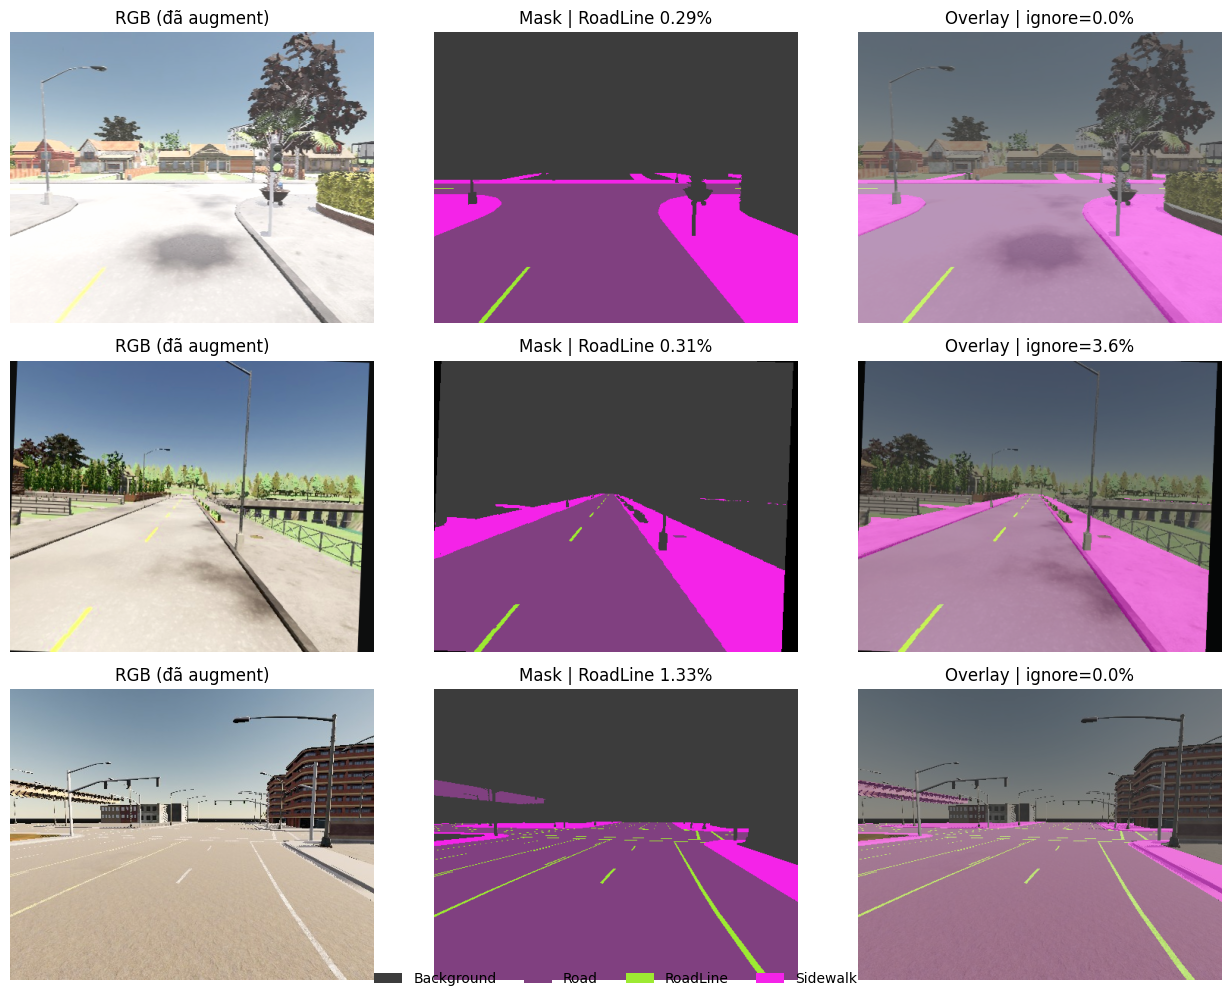

In [12]:
# Kiểm tra mắt thường: ảnh và mask phải khớp nhau, vạch kẻ phải còn thấy được sau resize.
def denorm(t):
    x = t.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return x.clip(0, 1)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for r in range(3):
    img, msk = train_ds[random.randrange(len(train_ds))]
    m = msk.numpy()
    rl_pct = 100 * (m == RL_ID).mean() if RL_ID is not None else 0.0
    axes[r, 0].imshow(denorm(img));   axes[r, 0].set_title("RGB (đã augment)")
    axes[r, 1].imshow(colorize(m));   axes[r, 1].set_title(f"Mask | RoadLine {rl_pct:.2f}%")
    axes[r, 2].imshow(denorm(img));   axes[r, 2].imshow(colorize(m), alpha=0.55)
    axes[r, 2].set_title(f"Overlay | ignore={100*(m==IGNORE_INDEX).mean():.1f}%")
    for c in range(3):
        axes[r, c].axis("off")
handles = [plt.Rectangle((0, 0), 1, 1, fc=PALETTE[i] / 255) for i in range(NUM_CLASSES)]
fig.legend(handles, CLASS_NAMES, ncol=NUM_CLASSES, loc="lower center", frameon=False)
plt.tight_layout(); plt.show()

## 7. Class weights

`sqrt(median_freq / freq)`, clip `[0.5, WEIGHT_CLIP]`: tỉ số nhỏ giữa class nặng nhất và
nhẹ nhất là điều kiện để loss ổn định. `CLASS_WEIGHT_BOOST` nhân thêm tay cho `RoadLine` —
class quan trọng nhất với bám làn nhưng mỏng nhất, median-frequency một mình không đủ.

Số liệu lấy từ histogram đã tính sẵn lúc build blob (§5), không quét lại dataset.

In [13]:
def class_counts(raw_hist):
    """Gộp histogram raw ID theo class nhiệm vụ. Ô 255 = pixel bị ignore."""
    return np.bincount(LABEL_LUT.astype(np.int64), weights=raw_hist, minlength=256)


counts = class_counts(train_raw_hist)
ignored, counts = counts[IGNORE_INDEX], counts[:NUM_CLASSES]
total = counts.sum()
val_counts = class_counts(val_raw_hist)[:NUM_CLASSES]

present = counts > 0
freq = np.where(present, counts / max(total, 1), 1.0)
w = np.sqrt(np.median(freq[present]) / freq)
for nm, mul in CLASS_WEIGHT_BOOST.items():
    if nm in CLASS_NAMES:
        w[CLASS_NAMES.index(nm)] *= mul
w = np.clip(w, 0.5, WEIGHT_CLIP)
w[~present] = 0.0
class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)

print(f"pixel bị ignore: {100*ignored/(ignored+total):.2f}%\n")
print(f"{'id':>3} {'class':<13} {'%train':>9} {'%val':>9} {'weight':>8}")
for i in range(NUM_CLASSES):
    print(f"{i:>3} {CLASS_NAMES[i]:<13} {100*counts[i]/total:>8.4f}% "
          f"{100*val_counts[i]/val_counts.sum():>8.4f}% {w[i]:>8.3f}"
          + ("" if present[i] else "   <-- VẮNG MẶT"))
print(f"\ntỉ số weight cao nhất / thấp nhất = {w[present].max()/w[present].min():.1f}x")

pixel bị ignore: 0.00%

 id class            %train      %val   weight
  0 Background     53.2491%  49.7446%    0.652
  1 Road           38.3854%  42.2178%    0.767
  2 RoadLine        1.5390%   3.4528%    4.000
  3 Sidewalk        6.8265%   4.5849%    1.820

tỉ số weight cao nhất / thấp nhất = 6.1x


## 8. Model, loss, optimizer, scheduler, EMA

**Loss.** Dice chỉ tính trên class nhiệm vụ: Background chiếm 60–70% pixel, để nó trong Dice
nghĩa là phần lớn loss đến từ việc đoán đúng bầu trời — gradient gần như bằng 0 nhưng vẫn
làm loãng tín hiệu từ RoadLine. CE thêm label smoothing để giảm overconfidence ở biên
Road/RoadLine, nơi nhãn vốn đã mơ hồ ở độ phân giải này.

**EMA.** Trung bình trượt trọng số qua các step, chi phí một lần copy tham số mỗi step.
Vòng lặp train đánh giá **cả hai** (raw và EMA) rồi giữ cái tốt hơn.

In [14]:
# =============================================================================
# TẠI SAO BẢN CŨ NỔ "CUDA error: misaligned address"
# =============================================================================
# DataParallel KHÔNG copy từng tham số một. Mỗi forward nó nối toàn bộ tensor float32
# của model thành một buffer phẳng (~10 MB mỗi buffer), broadcast sang GPU1, rồi cắt
# view ra. Offset của mỗi view = tổng số phần tử của các tensor đứng TRƯỚC nó.
#
# Kernel convolution vectorised của cuDNN nạp dữ liệu theo float4 -> cần địa chỉ chia
# hết cho 16 byte = 4 float. Nghĩa là mọi tensor trong buffer phải có numel chia hết
# cho 4, nếu không mọi tensor phía sau nó bị đẩy lệch.
#
# SCSEModule của smp phá đúng điều kiện đó:
#     self.sSE = nn.Sequential(nn.Conv2d(C, 1, 1), nn.Sigmoid())   -> bias numel = 1
#     self.cSE = ... nn.Conv2d(C, C // 16, 1) ...                  -> bias numel = C//16
# Hai decoder block cuối có C = 32 và C = 16 nên bias cSE là 2 và 1 phần tử. Chỉ cần
# MỘT tensor lẻ là toàn bộ conv phía sau trong cùng buffer lệch 4 byte. Đếm thử trên
# Unet/resnet34 + scse: 56 tham số lệch, trong đó 25 là weight của conv, bắt đầu ngay
# từ decoder block 0 — khớp với traceback trỏ vào `decoder.py -> conv1`. Lỗi chỉ xuất
# hiện khi USE_MULTI_GPU = True vì 1 GPU không hề có bước nối buffer này.
#
# Cách vá: bỏ bias của 3 conv 1x1 trong SCSE. Cả ba đi thẳng vào Sigmoid/ReLU và được
# khởi tạo ngẫu nhiên (decoder không có trọng số pretrained), nên bỏ bias chỉ đưa cổng
# attention về 0.5 lúc khởi tạo — rẻ hơn nhiều so với vứt hẳn attention hay bỏ GPU thứ hai.
# =============================================================================

DP_BUFFER_BYTES = 10 * 1024 * 1024      # = buffer_size của comm.broadcast_coalesced


def dp_misaligned(module, buffer_bytes=DP_BUFFER_BYTES, align=16):
    """Mô phỏng cách DataParallel gom buffer, trả về các tham số sẽ lệch địa chỉ."""
    bad, used, offset = [], 0, 0
    for name, p in module.named_parameters():
        nbytes = p.numel() * p.element_size()
        if used > 0 and used + nbytes > buffer_bytes:    # take_tensors mở buffer mới
            used, offset = 0, 0                          # buffer mới -> căn lại từ 0
        if offset % align:
            bad.append((name, tuple(p.shape), offset % align))
        used += nbytes
        offset += nbytes
    return bad


def _conv_no_bias(conv):
    new = nn.Conv2d(conv.in_channels, conv.out_channels, conv.kernel_size,
                    stride=conv.stride, padding=conv.padding,
                    dilation=conv.dilation, groups=conv.groups, bias=False)
    with torch.no_grad():
        new.weight.copy_(conv.weight)
    return new


def align_scse_(module):
    """Thay 3 conv 1x1 của mọi SCSEModule bằng bản bias=False. Trả về số module đã vá."""
    n = 0
    for m in module.modules():
        if type(m).__name__ == "SCSEModule":
            m.cSE[1] = _conv_no_bias(m.cSE[1])
            m.cSE[3] = _conv_no_bias(m.cSE[3])
            m.sSE[0] = _conv_no_bias(m.sSE[0])
            n += 1
    return n


# --- Dựng model trên CPU trước: vá xong mới đẩy lên GPU ------------------------
# Unet decoder upsample tới ĐÚNG độ phân giải đầu vào, skip connection từ từng tầng
# encoder -> giữ được cấu trúc mảnh như vạch kẻ đường.
model = smp.Unet(
    encoder_name=ENCODER_NAME,
    encoder_weights="imagenet",
    decoder_attention_type=DECODER_ATTENTION,
    in_channels=3,
    classes=NUM_CLASSES,
)

SCSE_BIAS_FREE = False
if USE_MULTI_GPU:
    _bad = dp_misaligned(model)
    if _bad:
        print(f"alignment: {len(_bad)} tham số lệch địa chỉ dưới DataParallel "
              f"(vd {_bad[0][0]} {_bad[0][1]}, lệch {_bad[0][2]} byte)")
        SCSE_BIAS_FREE = align_scse_(model) > 0
        _bad = dp_misaligned(model)
        print(f"  -> vá {'SCSE bias-free' if SCSE_BIAS_FREE else '(không có SCSE)'}: "
              f"còn {len(_bad)} tham số lệch")
    if _bad:
        # Không hạ BATCH_SIZE: train_loader ở §7 đã dựng với batch tổng 32 và LR ở §1
        # đã scale theo đúng con số đó. Một T4 15.6 GB vẫn đủ cho batch 32 @384x480 + AMP.
        print("  -> vẫn còn lệch, hạ xuống 1 GPU cho an toàn "
              "(đặt ALLOW_MULTI_GPU = False ở §1 để bỏ hẳn bước dò này).")
        USE_MULTI_GPU = False
    else:
        print("alignment: OK, mọi tham số căn 16 byte.")

model = model.to(DEVICE)
if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

print(f"{MODEL_ARCH}/{ENCODER_NAME} | attention={DECODER_ATTENTION}"
      f"{' (bias-free)' if SCSE_BIAS_FREE else ''} "
      f"| params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

# --- Multi-GPU (Kaggle T4 x2) -------------------------------------------------
# DataParallel: MỘT process, mỗi forward replicate model sang GPU1 rồi gom gradient về
# GPU0. Với Unet/resnet34 (~24M param -> ~98 MB broadcast mỗi step qua PCIe) chi phí đó
# chiếm ~5% thời gian một step, đổi lại ~1.8x throughput. Không dùng DDP vì DDP cần
# nhiều process, mà blob nén trong RAM (§5) sẽ bị nhân bản theo process.
#
# `model` (base module) VẪN là nơi giữ trọng số thật -> state_dict KHÔNG có tiền tố
# "module.", checkpoint tương thích ngược với bản 1 GPU và với phía IL/DRL.
train_net = nn.DataParallel(model) if USE_MULTI_GPU else model
if USE_MULTI_GPU:
    print("DataParallel: " + ", ".join(f"GPU{i}={torch.cuda.get_device_name(i)}"
                                       for i in range(N_GPU)))
else:
    print(f"1 GPU: {torch.cuda.get_device_name(0)}")

# Probe bằng ĐÚNG batch thật VÀ có backward: forward-only ở batch 2 không phát hiện được
# OOM của activation lúc train — nó sẽ nổ ở giữa epoch đầu tiên.
#
# Chia làm BA giai đoạn có torch.cuda.synchronize() xen giữa. Lỗi CUDA được báo BẤT ĐỒNG
# BỘ: không chặn lại ở đây thì exception nổ ở một lời gọi khác và traceback trỏ sai dòng.
# Giá phải trả là vài ms, đổi lại biết chính xác giai đoạn nào hỏng:
#   fp32 chết      -> channels_last / cudnn.benchmark chọn nhầm thuật toán
#   chỉ amp chết   -> kernel fp16 vectorised (cần địa chỉ chia hết cho 16 byte)
#   chỉ bwd chết   -> đường gom gradient của DataParallel
_x = torch.zeros(BATCH_SIZE, 3, IMAGE_HEIGHT, IMAGE_WIDTH, device=DEVICE)
if USE_CHANNELS_LAST:
    _x = _x.to(memory_format=torch.channels_last)

try:
    print("  probe [fp32 forward] ...", flush=True)
    with torch.no_grad():
        _y = train_net(_x)
    torch.cuda.synchronize()

    print("  probe [amp forward] ...", flush=True)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=USE_AMP):
        _y = train_net(_x)
    torch.cuda.synchronize()

    print("  probe [backward] ...", flush=True)
    with torch.amp.autocast("cuda", enabled=USE_AMP):
        _y = train_net(_x)
    _y.float().pow(2).mean().backward()
    torch.cuda.synchronize()
except Exception as _e:
    # cudaErrorMisalignedAddress / illegal access là lỗi STICKY: CUDA context đã hỏng,
    # mọi cell chạy sau đều lỗi theo. try/except ở đây chỉ để in hướng dẫn, KHÔNG cứu được.
    print("\nPROBE HỎNG:", type(_e).__name__, _e)
    print("Context CUDA đã hỏng -> Restart kernel, rồi thử theo thứ tự:\n"
          "  1) USE_CHANNELS_LAST = False (§1)  — thử trước, rẻ nhất về chất lượng\n"
          "  2) DECODER_ATTENTION = None  (§1)  — giữ 2 GPU, bỏ attention\n"
          "  3) torch.backends.cudnn.benchmark = False (§1)\n"
          "  4) ALLOW_MULTI_GPU = False   (§1)  — chắc ăn nhất, chậm ~1.8x")
    raise

assert _y.shape[-2:] == (IMAGE_HEIGHT, IMAGE_WIDTH), "logits không cùng độ phân giải với input"
print(f"forward+backward ok: {tuple(_x.shape)} -> {tuple(_y.shape)}")
for _i in range(max(N_GPU, 1)):
    _p = torch.cuda.get_device_properties(_i)
    print(f"  GPU{_i}: đỉnh {torch.cuda.max_memory_allocated(_i)/1e9:.2f} GB "
          f"/ {_p.total_memory/1e9:.1f} GB")

model.zero_grad(set_to_none=True)
del _x, _y
gc.collect(); torch.cuda.empty_cache()
for _i in range(max(N_GPU, 1)):
    torch.cuda.reset_peak_memory_stats(_i)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

alignment: 56 tham số lệch địa chỉ dưới DataParallel (vd decoder.blocks.0.conv2.0.weight (256, 256, 3, 3), lệch 4 byte)
  -> vá SCSE bias-free: còn 0 tham số lệch
alignment: OK, mọi tham số căn 16 byte.
unet/resnet34 | attention=scse (bias-free) | params: 24.55 M
DataParallel: GPU0=Tesla T4, GPU1=Tesla T4
  probe [fp32 forward] ...
  probe [amp forward] ...
  probe [backward] ...
forward+backward ok: (32, 3, 384, 480) -> (32, 4, 384, 480)
  GPU0: đỉnh 5.44 GB / 15.6 GB
  GPU1: đỉnh 5.32 GB / 15.6 GB


In [15]:
ce_loss = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX,
                              label_smoothing=LABEL_SMOOTHING)
dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True,
                                classes=TASK_CLASS_IDS, ignore_index=IGNORE_INDEX)

def criterion(logits, target):
    return (1 - DICE_WEIGHT) * ce_loss(logits, target) + DICE_WEIGHT * dice_loss(logits, target)


# Label smoothing khiến CE KHÔNG THỂ về 0 kể cả khi dự đoán hoàn hảo: mục tiêu đã bị làm
# mềm nên loss tối thiểu bằng entropy của chính phân phối mềm đó. Biết sàn này thì đoạn
# phẳng ở cuối biểu đồ loss là chuyện bình thường, không phải model ngừng học.
if LABEL_SMOOTHING > 0:
    _p = 1 - LABEL_SMOOTHING + LABEL_SMOOTHING / NUM_CLASSES
    _q = LABEL_SMOOTHING / NUM_CLASSES
    CE_FLOOR = float(-_p * np.log(_p) - (NUM_CLASSES - 1) * _q * np.log(_q))
else:
    CE_FLOOR = 0.0
LOSS_FLOOR = (1 - DICE_WEIGHT) * CE_FLOOR
print(f"label_smoothing={LABEL_SMOOTHING}, {NUM_CLASSES} class -> "
      f"sàn CE = {CE_FLOOR:.4f}, sàn loss = {LOSS_FLOOR:.4f}")

# Bias/BatchNorm không chịu weight decay (thực hành chuẩn của AdamW).
decay, no_decay = [], []
for n, p in model.named_parameters():
    if p.requires_grad:
        (no_decay if p.ndim <= 1 or n.endswith(".bias") else decay).append(p)
optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": WEIGHT_DECAY},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=LEARNING_RATE, betas=(0.9, 0.999),
)

TOTAL_STEPS = len(train_loader) * EPOCHS

def lr_at(step):
    """Warmup tuyến tính rồi cosine xuống MIN_LR_RATIO."""
    if step < WARMUP_STEPS:
        return (step + 1) / WARMUP_STEPS
    p = min((step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS), 1.0)
    return MIN_LR_RATIO + (1 - MIN_LR_RATIO) * 0.5 * (1 + np.cos(np.pi * p))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_at)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

ema_model, ema_net = None, None
if USE_EMA:
    # AveragedModel bọc BASE model (không phải train_net): trọng số EMA nằm ngoài
    # DataParallel nên state_dict của nó cũng sạch tiền tố "module.".
    ema_model = torch.optim.swa_utils.AveragedModel(
        model, multi_avg_fn=torch.optim.swa_utils.get_ema_multi_avg_fn(EMA_DECAY),
        use_buffers=True)
    # Riêng lúc EVAL thì vẫn chạy EMA trên cả 2 GPU (val 10k ảnh, chạy mỗi epoch). Wrapper
    # tạo một lần, bọc đúng module mà AveragedModel cập nhật in-place.
    ema_net = nn.DataParallel(ema_model.module) if USE_MULTI_GPU else ema_model.module
    print(f"EMA bật, decay={EMA_DECAY}")

print(f"{TOTAL_STEPS:,} step | warmup {WARMUP_STEPS} | lr {LEARNING_RATE:.1e} -> "
      f"{LEARNING_RATE*MIN_LR_RATIO:.1e}")
print(f"Dice tính trên class: {[CLASS_NAMES[i] for i in TASK_CLASS_IDS]}")

label_smoothing=0.02, 4 class -> sàn CE = 0.0944, sàn loss = 0.0566
EMA bật, decay=0.999
3,120 step | warmup 500 | lr 4.2e-04 -> 8.5e-06
Dice tính trên class: ['Road', 'RoadLine', 'Sidewalk']


## 9. Vòng lặp huấn luyện

| Metric | Ý nghĩa |
|--------|---------|
| `lane` | **Metric chọn checkpoint** — mIoU trên Road/RoadLine/Sidewalk |
| `task` | mIoU trên class nhiệm vụ (bỏ Background), chỉ tính class có mặt trong ground-truth |
| `all` | Có cả Background — luôn cao hơn, chỉ để tham chiếu |
| `drive` | IoU nhị phân của vùng `Road ∪ RoadLine` — gần nhất với "model có bám đúng mặt đường không" |

Không dùng `mIoU_all` để chọn model vì Background dễ đến mức IoU của nó luôn > 0.9: nó vừa
làm phẳng đường cong vừa che mất việc RoadLine đang tệ dần.

In [16]:
try:
    _libc = ctypes.CDLL("libc.so.6")      # malloc_trim chỉ có trên Linux (Kaggle)
except OSError:
    _libc = None


def ram_report(tag=""):
    """RSS của cha và USS (phần KHÔNG chia sẻ) của từng worker.

    mem_trim() chỉ trả về một con số tổng, nên khi RAM tăng bạn không biết cha hay worker
    đang phình. USS tách được hai thứ đó: blob nén (§5) là bộ nhớ chia sẻ qua fork nên
    KHÔNG được tính vào USS của worker — con số worker tăng dần nghĩa là rò rỉ thật.
    """
    me = psutil.Process()
    kids = me.children(recursive=True)
    uss = 0.0
    for c in kids:
        try:
            uss += c.memory_full_info().uss / 1e9
        except (psutil.NoSuchProcess, psutil.AccessDenied):
            pass
    return me.memory_info().rss / 1e9, len(kids), uss


def mem_trim():
    """Gom rác Python/CUDA và trả arena đã free về OS. Trả về RAM đang dùng (GB)."""
    gc.collect()
    torch.cuda.empty_cache()
    if _libc is not None:
        _libc.malloc_trim(0)
    vm = psutil.virtual_memory()
    return (vm.total - vm.available) / 1e9


def update_confmat(cm, pred, target):
    k = target != IGNORE_INDEX
    idx = target[k].to(torch.int64) * NUM_CLASSES + pred[k].to(torch.int64)
    cm += torch.bincount(idx, minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)
    return cm


def summarize(cm):
    cmd = cm.double()
    tp = cmd.diag()
    iou = (tp / (cmd.sum(0) + cmd.sum(1) - tp).clamp(min=1)).cpu().numpy()
    support = cmd.sum(1).cpu().numpy()
    seen = support > 0
    task = np.zeros(NUM_CLASSES, bool); task[TASK_CLASS_IDS] = True
    sel = seen & task

    # IoU nhị phân của hợp Road + RoadLine, đọc thẳng từ confusion matrix.
    cmn = cm.cpu().numpy().astype(np.float64)
    d = np.zeros(NUM_CLASSES, bool); d[DRIVABLE_IDS] = True
    tp_d = cmn[np.ix_(d, d)].sum()
    denom = tp_d + cmn[np.ix_(~d, d)].sum() + cmn[np.ix_(d, ~d)].sum()

    return {
        "miou_task": float(iou[sel].mean()) if sel.any() else 0.0,
        "miou_all":  float(iou[seen].mean()) if seen.any() else 0.0,
        "iou_drive": float(tp_d / max(denom, 1)) if DRIVABLE_IDS else float("nan"),
        "iou": iou,
        "support": support,
    }


# Phân định CPU-bound hay GPU-bound. `loss.item()` đã ép đồng bộ mỗi step nên thời gian
# "compute" có tính cả GPU; phần "wait" là lúc next(loader) bị chặn vì worker chưa kịp
# trả batch. wait > ~40% nghĩa là 4 vCPU đang là nút thắt (augmentation quang học +
# giải mã JPEG), không phải hai con T4.
STEP_STATS = {}


def run_epoch(loader, train, epoch=None, net=None, tag=None):
    net = net if net is not None else train_net
    net.train(train)
    total, nstep = 0.0, 0
    t_wait = t_comp = 0.0
    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64, device=DEVICE)
    tag = tag or ("train" if train else " val ")
    desc = f"E{epoch+1:02d}/{EPOCHS} [{tag}]" if epoch is not None else tag

    with torch.enable_grad() if train else torch.no_grad():
        pbar = tqdm(loader, desc=desc, leave=False, unit="b")
        _t = time.perf_counter()
        for images, masks in pbar:
            t_wait += time.perf_counter() - _t
            _t = time.perf_counter()          # mốc mới: từ đây trở đi là compute
            images = images.to(DEVICE, non_blocking=True)
            if USE_CHANNELS_LAST:
                images = images.to(memory_format=torch.channels_last)
            # .long() làm trên GPU: dataset trả uint8 để hàng đợi worker nhẹ đi 8 lần.
            masks = masks.to(DEVICE, non_blocking=True).long()

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = net(images)
                loss = criterion(logits, masks)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                if ema_model is not None:
                    # Cập nhật từ `model` (base) chứ KHÔNG phải `net`: dưới DataParallel,
                    # `net` chỉ là wrapper, trọng số thật nằm ở base module.
                    ema_model.update_parameters(model)
            else:
                update_confmat(cm, logits.argmax(1), masks)

            total += loss.item(); nstep += 1
            pbar.set_postfix(loss=f"{total/nstep:.4f}",
                             lr=f"{optimizer.param_groups[0]['lr']:.2e}")
            t_comp += time.perf_counter() - _t
            _t = time.perf_counter()
        pbar.close()

    STEP_STATS[tag.strip()] = t_wait / max(t_wait + t_comp, 1e-9)
    avg = total / max(nstep, 1)
    return (avg, None) if train else (avg, summarize(cm))

In [17]:
HKEYS = ("train_loss", "val_loss", "lane_miou", "miou_task", "miou_all",
         "iou_drive", "lr", "sec")
history = {k: [] for k in HKEYS}
best, best_src, patience = -1.0, "raw", 0
start_epoch = 0
t_start = time.time()

# --- Tiếp tục từ session trước ----------------------------------------------
if RESUME and LAST_PATH.exists():
    _lc = torch.load(LAST_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(_lc["model_state_dict"])
    if ema_model is not None and _lc.get("ema_state_dict") is not None:
        ema_model.module.load_state_dict(_lc["ema_state_dict"])
    optimizer.load_state_dict(_lc["optimizer_state_dict"])
    scheduler.load_state_dict(_lc["scheduler_state_dict"])
    scaler.load_state_dict(_lc["scaler_state_dict"])
    history = _lc["history"]
    best, best_src, patience = _lc["best"], _lc["best_src"], _lc["patience"]
    start_epoch = _lc["epoch"] + 1
    print(f"Tiếp tục từ epoch {start_epoch + 1} | best lane_mIoU = {best:.4f}")
    del _lc
elif RESUME:
    print(f"[!] RESUME=True nhưng không thấy {LAST_PATH} — train từ đầu.")


def lane_score(m):
    """mIoU trên các class làn thật sự có mặt trong ground-truth của val."""
    ids = [i for i in LANE_IDS if m["support"][i] > 0]
    return float(np.mean([m["iou"][i] for i in ids])) if ids else m["miou_task"]


for ep in range(start_epoch, EPOCHS):
    t0 = time.time()
    tr_loss, _ = run_epoch(train_loader, True, ep)
    va_loss, m_raw = run_epoch(val_loader, False, ep)

    cand = [("raw", m_raw)]
    if ema_model is not None and ep >= EMA_EVAL_START:
        _, m_ema = run_epoch(val_loader, False, ep, net=ema_net, tag=" ema ")
        cand.append(("ema", m_ema))
    src, m = max(cand, key=lambda c: lane_score(c[1]))

    score, dt = lane_score(m), time.time() - t0
    lr_now = optimizer.param_groups[0]["lr"]
    for k, v in zip(HKEYS, (tr_loss, va_loss, score, m["miou_task"],
                            m["miou_all"], m["iou_drive"], lr_now, dt)):
        history[k].append(v)

    ram = mem_trim()
    _rss, _nk, _uss = ram_report()
    worst = sorted((i for i in TASK_CLASS_IDS if m["support"][i] > 0),
                   key=lambda i: m["iou"][i])[:3]
    rl_txt = f" RoadLine={m['iou'][RL_ID]:.3f}" if RL_ID is not None else ""
    print(f"E{ep+1:02d}/{EPOCHS} train={tr_loss:.4f} val={va_loss:.4f} "
          f"lane={score:.4f}({src}) task={m['miou_task']:.4f} "
          f"drive={m['iou_drive']:.4f}{rl_txt} lr={lr_now:.2e} {dt/60:.1f}m "
          f"ram={ram:.1f}G  | yếu nhất: "
          + ", ".join(f"{CLASS_NAMES[i]}={m['iou'][i]:.2f}" for i in worst))
    # Cột `cha` tăng dần -> rò rỉ trong tiến trình chính. Cột `worker` tăng dần -> rò rỉ
    # trong DataLoader (đã bị chặn bởi PERSISTENT_WORKERS=False + mallopt ở §1).
    # `wait` là tỉ lệ thời gian GPU phải chờ dữ liệu; > 40% thì nút thắt là 4 vCPU.
    print(f"     ram: cha {_rss:.2f}G | {_nk} worker riêng {_uss:.2f}G | tổng {ram:.1f}G"
          f"   | wait train {100*STEP_STATS.get('train', 0):.0f}% "
          f"val {100*STEP_STATS.get('val', 0):.0f}%")

    if score > best:
        best, best_src, patience = score, src, 0
        torch.save({
            "epoch": ep,
            "model_state_dict": (model if src == "raw" else ema_model.module).state_dict(),
            "weights_source": src,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_lane_miou": best, "best_miou_task": m["miou_task"],
            "miou_all": m["miou_all"], "iou_drivable": m["iou_drive"],
            "per_class_iou": m["iou"].tolist(),
            "loss_floor": LOSS_FLOOR,
            # Hợp đồng nhãn + tiền xử lý đi kèm checkpoint để IL/DRL không phải chép tay.
            "num_classes": NUM_CLASSES, "class_names": CLASS_NAMES,
            "task_scheme": TASK_SCHEME, "lane_ids": LANE_IDS,
            "task_class_ids": TASK_CLASS_IDS, "sky_as_class": SKY_AS_CLASS, "sky_id": SKY_ID,
            "raw_to_train": {int(k): int(v) for k, v in RAW_TO_TRAIN.items()},
            "label_lut": LABEL_LUT.tolist(), "ignore_index": IGNORE_INDEX,
            "model_arch": MODEL_ARCH, "encoder_name": ENCODER_NAME,
            # Thiếu hai key này thì phía IL/DRL dựng lại Unet không có nhánh
            # attention -> load_state_dict báo missing keys.
            "decoder_attention_type": DECODER_ATTENTION,
            "scse_bias_free": SCSE_BIAS_FREE,
            "image_height": IMAGE_HEIGHT, "image_width": IMAGE_WIDTH,
            "norm_mean": IMAGENET_MEAN, "norm_std": IMAGENET_STD,
            "thin_raw_ids": THIN_RAW_IDS, "thin_cover_thresh": THIN_COVER_THRESH,
            "collect_fps": COLLECT_FPS, "control_dt": CONTROL_DT,
        }, CHECKPOINT_PATH)
        print(f"     -> lưu checkpoint ({src}, lane_mIoU={best:.4f})")
    else:
        patience += 1

    # Snapshot "last" ghi ở MỌI epoch, kể cả epoch không cải thiện — đây là thứ cho phép
    # RESUME=True đi tiếp sau khi Kaggle cắt session ở 12h.
    torch.save({
        "epoch": ep,
        "model_state_dict": model.state_dict(),
        "ema_state_dict": ema_model.module.state_dict() if ema_model is not None else None,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "history": history, "best": best, "best_src": best_src, "patience": patience,
    }, LAST_PATH)

    if patience >= EARLY_STOP_PATIENCE:
        print(f"Early stop: {EARLY_STOP_PATIENCE} epoch không cải thiện.")
        break

print(f"\nXong. best lane_mIoU = {best:.4f} ({best_src}) "
      f"| tổng {(time.time()-t_start)/60:.1f} phút | {CHECKPOINT_PATH}")

# Hợp đồng với train_il.ipynb: DataParallel không được rò tiền tố "module." vào
# checkpoint. Lỗi này im lặng cho tới lúc phía IL gọi load_state_dict và báo thiếu MỌI key.
_keys = torch.load(CHECKPOINT_PATH, map_location="cpu",
                   weights_only=False)["model_state_dict"].keys()
assert not any(k.startswith("module.") for k in _keys), \
    "state_dict dính tiền tố 'module.' — đã lưu nhầm bản DataParallel."
print("checkpoint sạch tiền tố 'module.' — train_il.ipynb nạp được trực tiếp.")
del _keys

E01/20 [train]:   0%|          | 0/156 [00:00<?, ?b/s]

E01/20 [ val ]:   0%|          | 0/32 [00:00<?, ?b/s]

E01/20 train=0.7726 val=0.3759 lane=0.7248(raw) task=0.7248 drive=0.9626 RoadLine=0.639 lr=1.33e-04 4.5m ram=8.9G  | yếu nhất: Sidewalk=0.61, RoadLine=0.64, Road=0.93
     ram: cha 7.57G | 8 worker riêng 0.00G | tổng 8.9G   | wait train 1% val 5%
     -> lưu checkpoint (raw, lane_mIoU=0.7248)


E02/20 [train]:   0%|          | 0/156 [00:00<?, ?b/s]

E02/20 [ val ]:   0%|          | 0/32 [00:00<?, ?b/s]

...

E19/20 train=0.2099 val=0.2305 lane=0.8906(ema) task=0.8906 drive=0.9876 RoadLine=0.887 lr=1.21e-05 5.2m ram=19.8G  | yếu nhất: Sidewalk=0.81, RoadLine=0.89, Road=0.98
     ram: cha 18.23G | 12 worker riêng 0.00G | tổng 19.8G   | wait train 1% val 5%


E20/20 [train]:   0%|          | 0/156 [00:00<?, ?b/s]

E20/20 [ val ]:   0%|          | 0/32 [00:00<?, ?b/s]

E20/20 [ ema ]:   0%|          | 0/32 [00:00<?, ?b/s]

E20/20 train=0.2101 val=0.2315 lane=0.8909(ema) task=0.8909 drive=0.9877 RoadLine=0.887 lr=8.49e-06 5.2m ram=20.4G  | yếu nhất: Sidewalk=0.81, RoadLine=0.89, Road=0.98
     ram: cha 18.77G | 12 worker riêng 0.00G | tổng 20.4G   | wait train 1% val 5%

Xong. best lane_mIoU = 0.8917 (raw) | tổng 119.8 phút | /kaggle/working/best_carla_lane_seg.pth
checkpoint sạch tiền tố 'module.' — train_il.ipynb nạp được trực tiếp.


## 10. Biểu đồ huấn luyện

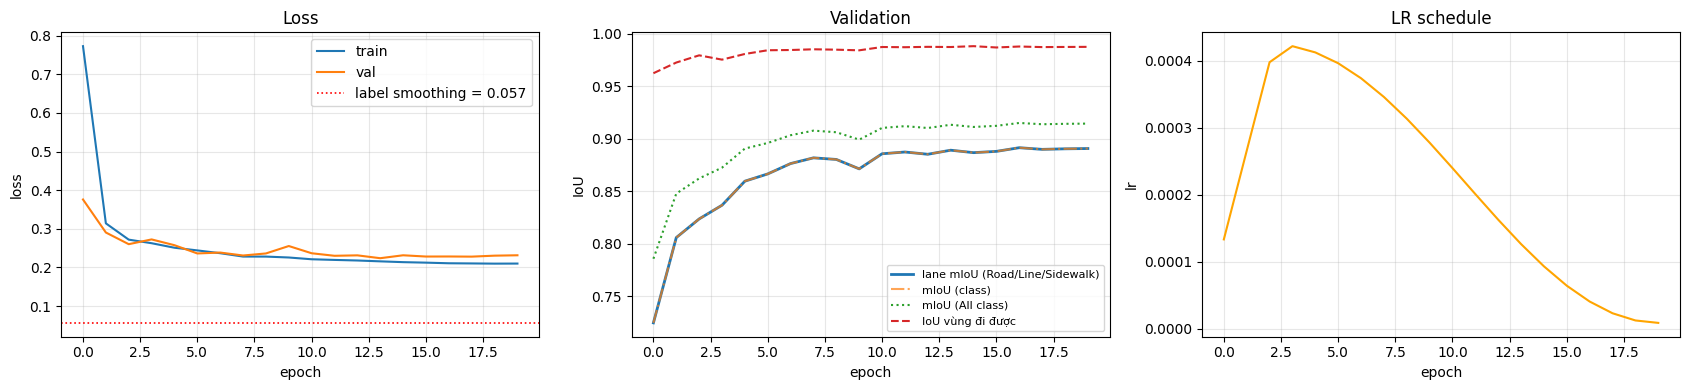

trung bình 303 s/epoch


In [31]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
if LOSS_FLOOR > 0:
    # Phần loss KHÔNG THỂ giảm do label smoothing — không có đường này thì đoạn phẳng ở
    # cuối trông như model đã ngừng học.
    ax[0].axhline(LOSS_FLOOR, color="r", ls=":", lw=1.2,
                  label=f"label smoothing = {LOSS_FLOOR:.3f}")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_title("Loss"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(history["lane_miou"], label="lane mIoU (Road/Line/Sidewalk)", lw=2)
ax[1].plot(history["miou_task"], label="mIoU (class)", ls="-.", alpha=.7)
ax[1].plot(history["miou_all"],  label="mIoU (All class)", ls=":")
ax[1].plot(history["iou_drive"], label="IoU vùng đi được", ls="--")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("IoU"); ax[1].legend(fontsize=8)
ax[1].set_title("Validation"); ax[1].grid(alpha=.3)

ax[2].plot(history["lr"], c="orange")
ax[2].set_xlabel("epoch"); ax[2].set_ylabel("lr"); ax[2].set_title("LR schedule")
ax[2].grid(alpha=.3)
plt.tight_layout()
fig.savefig("training_history.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"trung bình {np.mean(history['sec']):.0f} s/epoch")

## 11. Đánh giá chi tiết — per-class IoU, confusion matrix, flip-TTA

Confusion matrix cho biết model **nhầm sang đâu**, không chỉ biết nó sai. Ô cần nhìn đầu
tiên là `RoadLine -> Road`: vạch kẻ bị nuốt vào mặt đường, lỗi trực tiếp làm bộ điều khiển
mất tham chiếu làn.

Flip-TTA (trung bình logits của ảnh gốc và ảnh lật ngang) thường thêm 0.5–1 điểm mIoU, chỉ
dùng lúc đánh giá/inference.

nạp checkpoint epoch 17 (raw), lane_mIoU=0.8917 mIoU_task=0.8917


eval val:   0%|          | 0/32 [00:00<?, ?it/s]

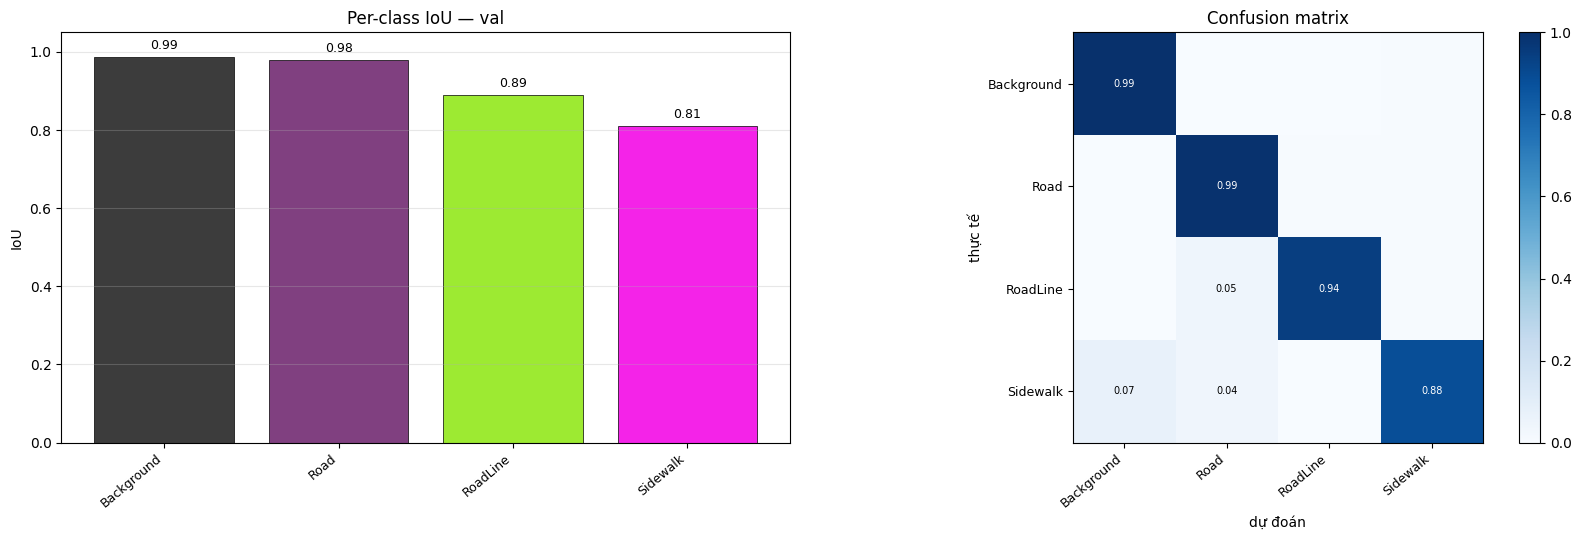


class              IoU    Prec  Recall      %pixel
Background      0.9861  0.9917  0.9943     49.745%
Road            0.9797  0.9902  0.9893     42.218%
RoadLine        0.8900  0.9389  0.9447      3.453%
Sidewalk        0.8113  0.9072  0.8847      4.585%

Nhầm lẫn lớn nhất (bỏ đường chéo):
  Sidewalk     -> bị đoán thành Background     7.5%
  RoadLine     -> bị đoán thành Road           4.7%
  Sidewalk     -> bị đoán thành Road           3.9%
  RoadLine     -> bị đoán thành Sidewalk       0.7%
  Road         -> bị đoán thành RoadLine       0.5%
  Road         -> bị đoán thành Sidewalk       0.4%

tầng                                   mIoU   class
lane  (Road/RoadLine/Sidewalk)       0.8937   ['Road', 'RoadLine', 'Sidewalk']
task  (mọi class trừ nền/trời)       0.8937   ['Road', 'RoadLine', 'Sidewalk']
all   (kể cả Background)             0.9168   ['Background', 'Road', 'RoadLine', 'Sidewalk']
IoU vùng đi được (Road ∪ RoadLine)   0.9884
Pixel accuracy                       0.9855


In [32]:
USE_TTA = True

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"nạp checkpoint epoch {ckpt['epoch']+1} ({ckpt['weights_source']}), "
      f"lane_mIoU={ckpt['best_lane_miou']:.4f} mIoU_task={ckpt['best_miou_task']:.4f}")


def predict_logits(net, x):
    with torch.amp.autocast("cuda", enabled=USE_AMP):
        out = net(x)
        if USE_TTA:
            out = out + torch.flip(net(torch.flip(x, dims=[3])), dims=[3])
    return out


cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64, device=DEVICE)
with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="eval val"):
        images = images.to(DEVICE, non_blocking=True)
        if USE_CHANNELS_LAST:
            images = images.to(memory_format=torch.channels_last)
        # train_net, không phải model: TTA = 2 forward x 10k ảnh, chạy trên cả 2 GPU.
        update_confmat(cm, predict_logits(train_net, images).argmax(1),
                       masks.to(DEVICE, non_blocking=True))

m = summarize(cm)
iou, support = m["iou"], m["support"]
cm_np = cm.cpu().numpy()
tp = np.diag(cm_np)
prec = tp / np.maximum(cm_np.sum(0), 1)
rec  = tp / np.maximum(cm_np.sum(1), 1)

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
ax[0].bar(range(NUM_CLASSES), iou, color=[PALETTE[i] / 255 for i in range(NUM_CLASSES)],
          edgecolor="black", lw=.5)
for i, v in enumerate(iou):
    ax[0].text(i, v + .02, f"{v:.2f}", ha="center", fontsize=9)
ax[0].set_xticks(range(NUM_CLASSES))
ax[0].set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)
ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("IoU"); ax[0].grid(axis="y", alpha=.3)
ax[0].set_title(f"Per-class IoU — val")

cmn = cm_np / np.maximum(cm_np.sum(1, keepdims=True), 1)
im = ax[1].imshow(cmn, cmap="Blues", vmin=0, vmax=1)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cmn[i, j] > 0.01:
            ax[1].text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                       fontsize=7, color="white" if cmn[i, j] > .5 else "black")
ax[1].set_xticks(range(NUM_CLASSES)); ax[1].set_yticks(range(NUM_CLASSES))
ax[1].set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)
ax[1].set_yticklabels(CLASS_NAMES, fontsize=9)
ax[1].set_xlabel("dự đoán"); ax[1].set_ylabel("thực tế")
ax[1].set_title("Confusion matrix")
plt.colorbar(im, ax=ax[1], fraction=.046)
plt.tight_layout()
fig.savefig("training_history_val.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\n{'class':<14}{'IoU':>8}{'Prec':>8}{'Recall':>8}{'%pixel':>12}")
for i in range(NUM_CLASSES):
    print(f"{CLASS_NAMES[i]:<14}{iou[i]:>8.4f}{prec[i]:>8.4f}{rec[i]:>8.4f}"
          f"{100*support[i]/support.sum():>11.3f}%" + ("" if support[i] else "  (vắng mặt)"))

print("\nNhầm lẫn lớn nhất (bỏ đường chéo):")
off = cmn.copy(); np.fill_diagonal(off, 0)
for gt, pr in zip(*np.unravel_index(np.argsort(off, axis=None)[::-1][:6], off.shape)):
    if off[gt, pr] > 0:
        print(f"  {CLASS_NAMES[gt]:<12} -> bị đoán thành {CLASS_NAMES[pr]:<12} "
              f"{100*off[gt,pr]:>5.1f}%")

# Bảng ba tầng cho báo cáo: một con số mIoU đơn lẻ là mập mờ vì Background (đã gộp cả bầu
# trời) là vùng lớn và dễ, nên mIoU_all luôn cao hơn mIoU_task đáng kể.
print("\n" + "=" * 60)
print(f"{'tầng':<34}{'mIoU':>9}   class")
for nm, ids in (("lane  (Road/RoadLine/Sidewalk)", LANE_IDS),
                ("task  (mọi class trừ nền/trời)", TASK_CLASS_IDS),
                ("all   (kể cả Background)",       list(range(NUM_CLASSES)))):
    vals = [iou[i] for i in ids if support[i] > 0]
    print(f"{nm:<34}{np.mean(vals):>9.4f}   {[CLASS_NAMES[i] for i in ids]}")
print("=" * 60)
print(f"{'IoU vùng đi được (Road ∪ RoadLine)':<34}{m['iou_drive']:>9.4f}")
print(f"{'Pixel accuracy':<34}{tp.sum()/max(cm_np.sum(), 1):>9.4f}")

## 12. Trực quan hoá dự đoán

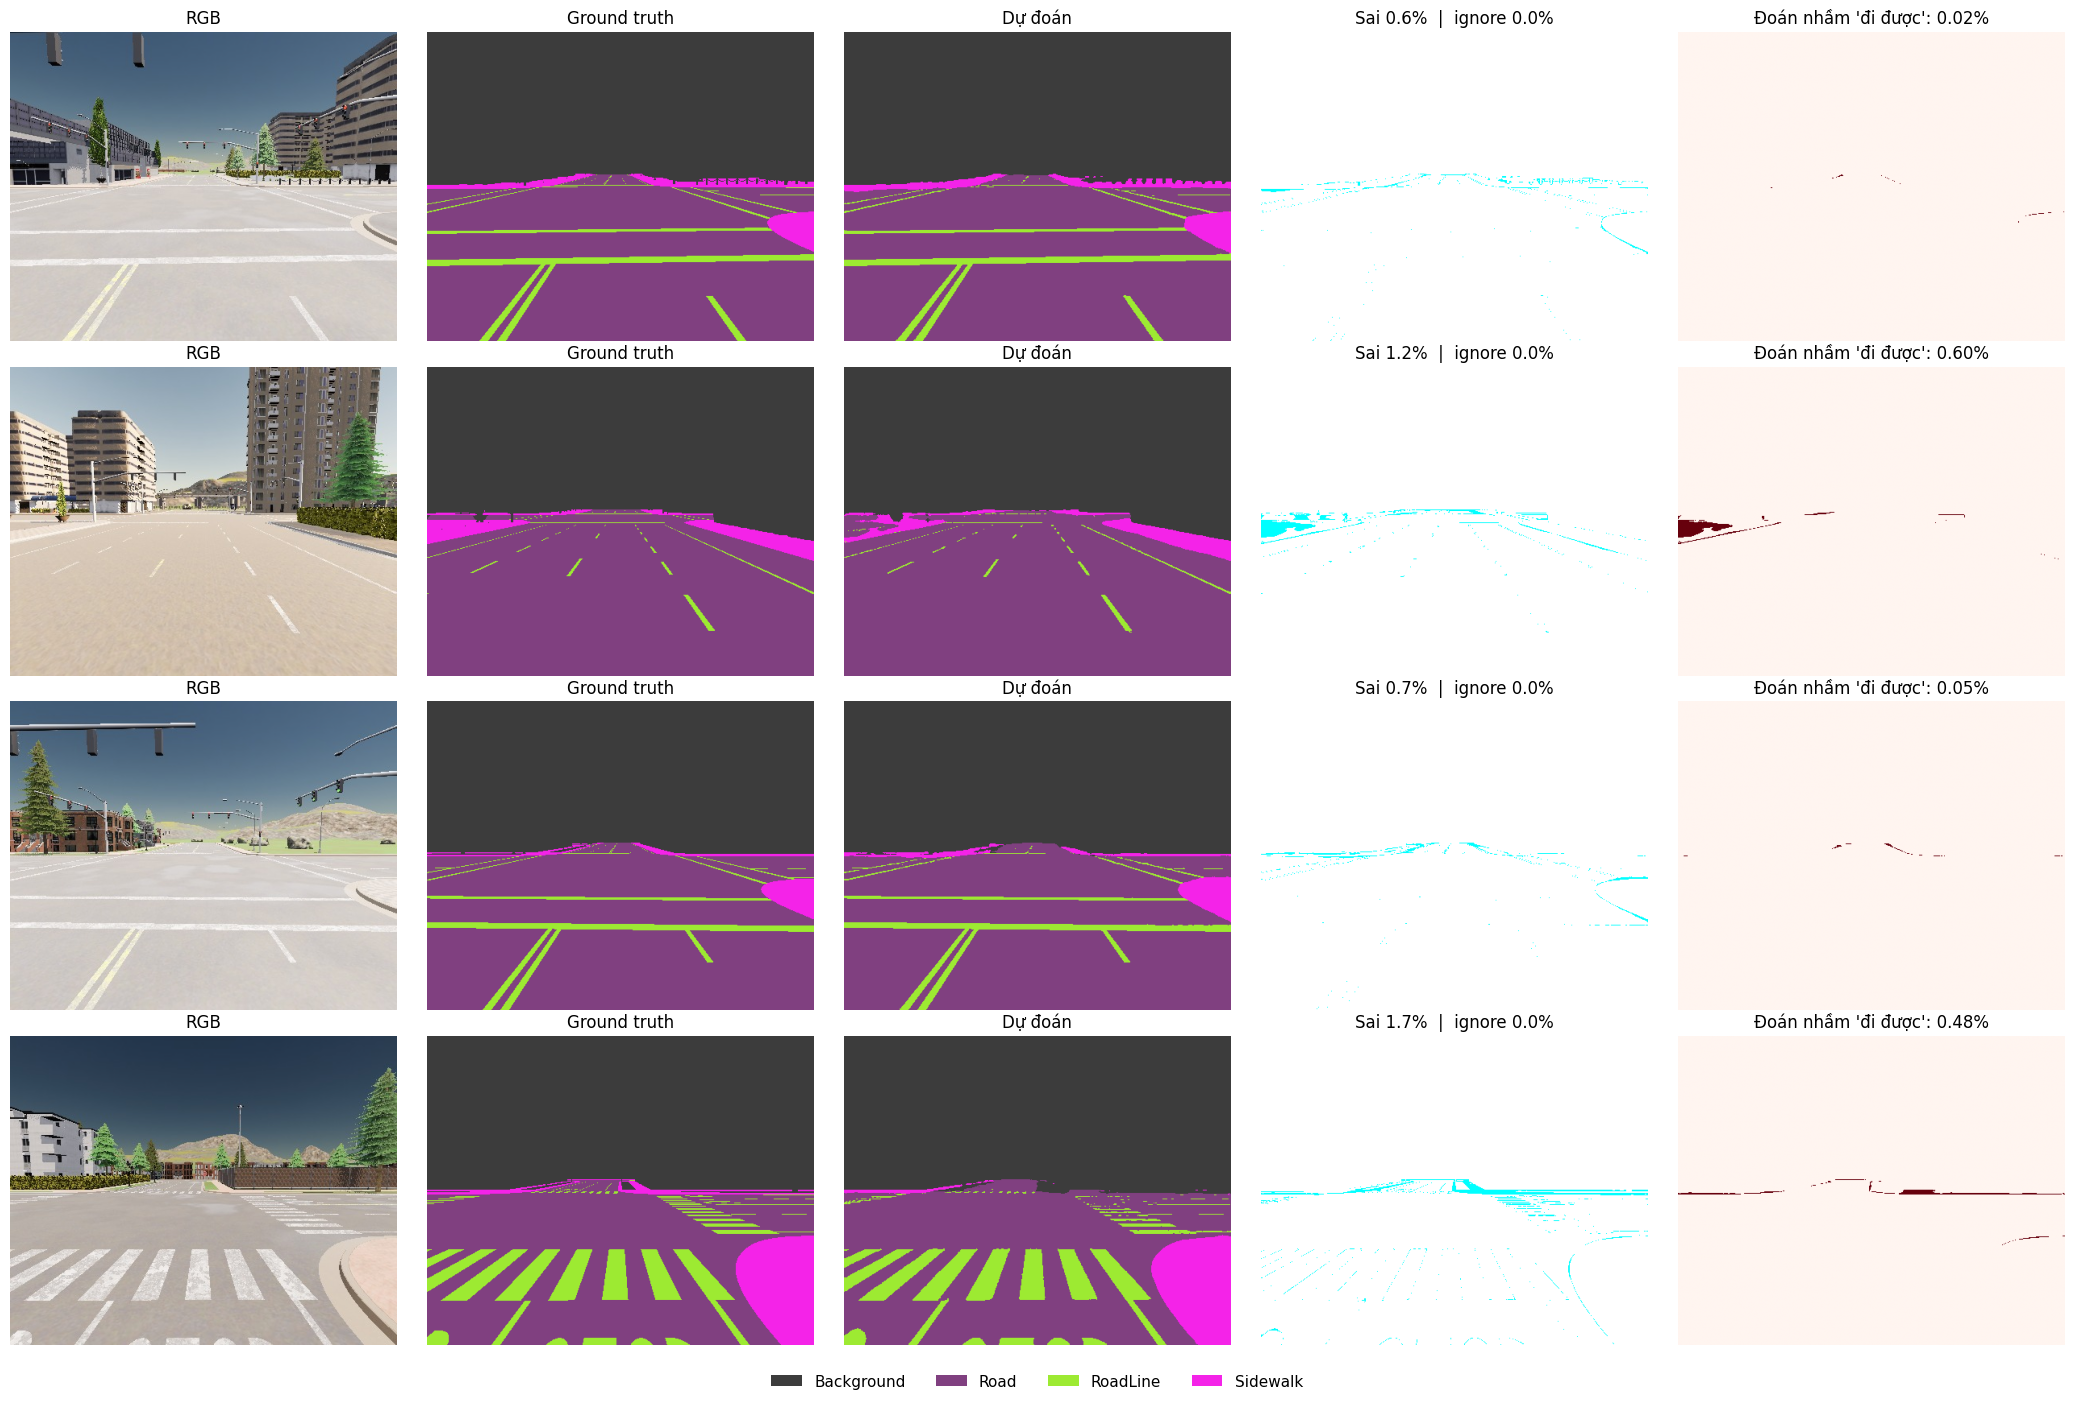

Rò rỉ vùng đi được trung bình: 0.289% pixel/ảnh
Vùng ignore còn lại chỉ là viền do A.Affine sinh ra (thường 0.0-0.5%); nếu ~25% thì IGNORE_UNLABELED đang bật — chạy lại §1 và §3.


In [30]:
N = 4
LEGEND_IN = 0.5                    # chiều cao dành cho legend, tính bằng inch
FIG_H     = 3.4 * N + LEGEND_IN
fig, axes = plt.subplots(N, 5, figsize=(21, FIG_H))
leaks = []
with torch.no_grad():
    for r in range(N):
        img, gt = val_ds[random.randrange(len(val_ds))]
        x = img.unsqueeze(0).to(DEVICE)
        if USE_CHANNELS_LAST:
            x = x.to(memory_format=torch.channels_last)
        pred = predict_logits(model, x).argmax(1)[0].cpu().numpy().astype(np.uint8)
        g = gt.numpy()

        ign = (g == IGNORE_INDEX)
        err = (pred != g) & ~ign
        vis = np.zeros((*err.shape, 3))
        vis[..., 0] = err.astype(float)
        vis[ign] = [0.75, 0.75, 0.75]      # vẽ vùng ignore để thấy nó rộng bao nhiêu

        # Chỉ số an toàn thật sự: model nói "đi được" ở nơi ground truth nói không.
        leak = np.isin(pred, DRIVABLE_IDS) & ~np.isin(g, DRIVABLE_IDS) & ~ign
        leaks.append(leak.mean())

        axes[r, 0].imshow(denorm(img));    axes[r, 0].set_title("RGB")
        axes[r, 1].imshow(colorize(g));    axes[r, 1].set_title("Ground truth")
        axes[r, 2].imshow(colorize(pred)); axes[r, 2].set_title("Dự đoán")
        axes[r, 3].imshow(1 - vis)
        axes[r, 3].set_title(f"Sai {100*err.mean():.1f}%  |  ignore {100*ign.mean():.1f}%")
        axes[r, 4].imshow(leak, cmap="Reds")
        axes[r, 4].set_title(f"Đoán nhầm 'đi được': {100*leak.mean():.2f}%")
        for c in range(5):
            axes[r, c].axis("off")

# handles = [plt.Rectangle((0, 0), 1, 1, fc=PALETTE[i] / 255) for i in range(NUM_CLASSES)]
# fig.legend(handles, CLASS_NAMES, ncol=NUM_CLASSES, loc="lower center", frameon=False)
# plt.tight_layout(); plt.show()

handles = [plt.Rectangle((0, 0), 1, 1, fc=PALETTE[i] / 255) for i in range(NUM_CLASSES)]
frac = LEGEND_IN / FIG_H
fig.tight_layout(rect=[0, frac, 1, 1])          # gọi TRƯỚC, chừa chỗ ở đáy
fig.legend(handles, CLASS_NAMES, ncol=NUM_CLASSES, loc="lower center",
           bbox_to_anchor=(0.5, frac * 0.15), frameon=False, fontsize=11)
fig.savefig(f"qualitative.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Rò rỉ vùng đi được trung bình: {100*np.mean(leaks):.3f}% pixel/ảnh")
print("Vùng ignore còn lại chỉ là viền do A.Affine sinh ra (thường 0.0-0.5%); nếu ~25% thì "
      "IGNORE_UNLABELED đang bật — chạy lại §1 và §3.")

## 13. Ghi chú cho bước Imitation Learning

Checkpoint lưu `state_dict` không có tiền tố `module.`, kèm `label_lut` đầy đủ:

```python
ck = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
seg = smp.Unet("resnet34", encoder_weights=None, decoder_attention_type="scse",
               in_channels=3, classes=ck["num_classes"])
seg.load_state_dict(ck["model_state_dict"]); seg.eval()
```

Ba nơi phải khớp byte-for-byte với `label_lut` trong checkpoint, nếu không model nhận sai
kênh mà **không** có lỗi nào báo (shape vẫn khớp):

| Nơi | Thứ phải khớp |
|-----|---------------|
| `behavior_cloning/train_il.ipynb` | `CLASS_NAMES`, `RAW_TO_TRAIN`, `PALETTE` (§2b tự kiểm) |
| `data_collection/carla_collector/schema.py` | `RAW_TO_TRAIN_LANE` — nguồn sự thật |
| `drl_training/policy/backbone.py` | `NUM_CLASSES` (số kênh vào của conv đầu tiên) |

Tiền xử lý ở IL phải **giống hệt** nhánh validation: resize `INTER_LINEAR` về
`(image_height, image_width)` rồi `Normalize(norm_mean, norm_std)`. Lệch bước này là nguyên
nhân phổ biến nhất khiến seg chạy tốt trong notebook nhưng nhiễu khi ghép vào IL.

**Muốn đẩy chỉ số cao hơn** (theo tác động giảm dần): chạy trọn lịch cosine (segmentation
kiếm phần lớn mIoU ở một phần ba cuối khi LR đã thấp) → crop bỏ phần trời, ~25–30% phía trên
ảnh không bao giờ chứa mặt đường, đổi lại ~1.4× độ phân giải hiệu dụng miễn phí (phải áp
dụng đồng bộ ở IL) → `ENCODER_NAME = "efficientnet-b2"` hoặc `resnet50` nếu còn VRAM → thu
lại dữ liệu CÓ NPC rồi mới bật `lane5`/`Vehicle`.

**Nếu OOM**: `BATCH_SIZE = 8` → `decoder_attention_type=None` → `ENCODER_NAME = "resnet18"`
(đừng hạ batch dưới 8, BatchNorm bắt đầu nhiễu).

## 14. Xuất TensorRT — ONNX → engine

Đường đi: **PyTorch → ONNX → engine TensorRT**. ONNX là bản trung gian *chạy được ở mọi
nơi*; file `.engine` thì gắn chặt với đúng GPU + đúng phiên bản TensorRT/driver của máy
build. Kaggle cho T4, còn CARLA của bạn gần như chắc chắn chạy trên GPU khác — nên
**§14a–14b xuất và kiểm tra ONNX ngay tại đây, §14c chỉ ghi ra script để build engine trên
máy đích**.

Bốn quyết định đã chốt sẵn trong `DeployNet`, mỗi cái vá một lỗi cụ thể:

| Quyết định | Vá lỗi gì |
|---|---|
| `argmax` nằm **trong** graph | output còn `1×384×480` int32 thay vì `1×4×384×480` float — bớt 16× dữ liệu copy GPU→CPU mỗi frame |
| `Normalize` nhúng vào graph (`BAKE_NORMALIZE`) | đúng thứ §13 cảnh báo: "lệch tiền xử lý là nguyên nhân phổ biến nhất khiến seg chạy tốt trong notebook nhưng nhiễu khi ghép vào IL". Nhúng vào rồi thì mean/std không thể chép sai nữa |
| `EXPORT_TTA = False` | flip-TTA ở §11 là **2 forward/ảnh**, xoá gần hết phần tốc độ TensorRT mang lại |
| Export ở FP32, để `trtexec --fp16` tự hạ | gọi `.half()` trước khi trace hay sinh NaN |

Về chuyện "cho nhẹ hơn": TensorRT chủ yếu đổi lấy **tốc độ**. Dung lượng giảm là do hạ độ
chính xác — FP16 còn ~1/2, INT8 ~1/4 so với FP32 (Unet/resnet34 ≈ 24.4M param ≈ 93 MB
FP32 → ~47 MB FP16). Muốn nhỏ hơn nữa thì phải pruning/distillation, không phải TensorRT.

In [ ]:
# =============================================================================
# 14a. PyTorch -> ONNX
# =============================================================================
import json, importlib.util, subprocess, sys   # json chưa được import ở §1
for _pkg, _pip in (("onnx", "onnx"), ("onnxruntime", "onnxruntime")):
    if importlib.util.find_spec(_pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pip], check=True)
import onnx, onnxruntime as ort

EXPORT_DIR = WORK_DIR / "deploy"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
ONNX_PATH  = EXPORT_DIR / "carla_lane_seg.onnx"

BAKE_NORMALIZE = True    # True -> input là RGB float32 thang 0..255, engine tự normalize
EXPORT_TTA     = False   # True -> nhúng flip-TTA, chậm 2x (xem bảng ở trên)

# --- Dựng lại model SẠCH từ checkpoint, trên CPU, FP32 ------------------------
# Không dùng biến `model` đang có: nó có thể đang ở channels_last/GPU và (nếu là bản
# EMA thắng) không phải bộ trọng số đã được §11 chấm điểm.
ck = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)

net = smp.Unet(encoder_name=ck["encoder_name"], encoder_weights=None,
               decoder_attention_type=ck["decoder_attention_type"],
               in_channels=3, classes=ck["num_classes"])
# BẮT BUỘC: bản vá SCSE bias-free ở §8 làm ĐỔI shape tham số. Bỏ dòng này thì
# load_state_dict báo lỗi shape ở cSE/sSE — và đây chính là chỗ script build trên máy
# đích hay chết, vì ở đó không có §8.
if ck.get("scse_bias_free"):
    align_scse_(net)
net.load_state_dict(ck["model_state_dict"])
net.eval().float()

H_EXP, W_EXP = ck["image_height"], ck["image_width"]


class DeployNet(nn.Module):
    """Gói tiền xử lý + argmax vào graph: client chỉ cần đưa ảnh, nhận thẳng mask."""

    def __init__(self, net, mean, std, bake_norm=True, tta=False):
        super().__init__()
        self.net, self.bake_norm, self.tta = net, bake_norm, tta
        # Nhân 255 sẵn để input là thang 0..255 (đúng thứ cv2.imread trả về), khỏi phải
        # chia 255 ở phía client — bớt một chỗ có thể làm sai.
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1) * 255.0)
        self.register_buffer("std",  torch.tensor(std).view(1, 3, 1, 1) * 255.0)

    def forward(self, x):
        if self.bake_norm:
            x = (x - self.mean) / self.std
        logits = self.net(x)
        if self.tta:
            logits = logits + torch.flip(self.net(torch.flip(x, dims=[3])), dims=[3])
        return logits.argmax(1).to(torch.int32)


deploy_net = DeployNet(net, ck["norm_mean"], ck["norm_std"],
                       BAKE_NORMALIZE, EXPORT_TTA).eval()

# Batch cố định = 1: CARLA chạy từng frame, engine batch tĩnh nhanh hơn và không dính
# lỗi shape lúc runtime.
dummy = (torch.rand(1, 3, H_EXP, W_EXP) * 255.0) if BAKE_NORMALIZE \
        else torch.randn(1, 3, H_EXP, W_EXP)

with torch.no_grad():
    torch.onnx.export(
        deploy_net, dummy, str(ONNX_PATH),
        input_names=["rgb"], output_names=["mask"],
        opset_version=17, do_constant_folding=True,
    )

onnx.checker.check_model(onnx.load(str(ONNX_PATH)))

# Metadata đi kèm file: engine build trên máy khác vẫn phải biết hợp đồng nhãn.
meta = {
    "onnx": ONNX_PATH.name,
    "input": {"name": "rgb", "shape": [1, 3, H_EXP, W_EXP], "dtype": "float32",
              "layout": "NCHW", "order": "RGB",
              "range": "0..255" if BAKE_NORMALIZE else "đã normalize",
              "normalize_in_graph": BAKE_NORMALIZE,
              "resize": "cv2.INTER_LINEAR về (W=%d, H=%d)" % (W_EXP, H_EXP)},
    "output": {"name": "mask", "shape": [1, H_EXP, W_EXP], "dtype": "int32"},
    "tta_in_graph": EXPORT_TTA,
    "num_classes": ck["num_classes"], "class_names": ck["class_names"],
    "task_scheme": ck["task_scheme"], "lane_ids": ck["lane_ids"],
    "task_class_ids": ck["task_class_ids"], "ignore_index": ck["ignore_index"],
    "norm_mean": list(ck["norm_mean"]), "norm_std": list(ck["norm_std"]),
    "encoder_name": ck["encoder_name"],
    "decoder_attention_type": ck["decoder_attention_type"],
    "scse_bias_free": bool(ck.get("scse_bias_free", False)),
    "raw_to_train": ck["raw_to_train"], "label_lut": ck["label_lut"],
    "control_dt": ck["control_dt"],
    "trained_epoch": int(ck["epoch"]) + 1,
    "lane_miou_pytorch_tta": float(ck["best_lane_miou"]),
}
(EXPORT_DIR / "deploy_meta.json").write_text(
    json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"ONNX: {ONNX_PATH}  ({ONNX_PATH.stat().st_size/1e6:.1f} MB)")
print(f"  rgb  (1,3,{H_EXP},{W_EXP}) float32 "
      f"{'0..255, normalize nằm trong graph' if BAKE_NORMALIZE else 'đã normalize sẵn'}")
print(f"  mask (1,{H_EXP},{W_EXP}) int32 | TTA trong graph: {EXPORT_TTA}")

In [ ]:
# =============================================================================
# 14b. Kiểm tra ONNX == PyTorch  (chạy TRƯỚC khi build engine)
# =============================================================================
# Sai ở bước này mà không biết thì sang tới engine sẽ debug rất mệt: lúc đó có thêm
# FP16, kernel fusion và layout của TRT chen vào, không còn tách được nguyên nhân.
N_CHECK_BATCH = 8

mean_t = torch.tensor(ck["norm_mean"]).view(1, 3, 1, 1)
std_t  = torch.tensor(ck["norm_std"]).view(1, 3, 1, 1)


def to_deploy_input(x_norm):
    """Tensor đã normalize (val_ds trả về) -> đúng định dạng input của ONNX/engine."""
    return (x_norm * std_t + mean_t) * 255.0 if BAKE_NORMALIZE else x_norm


sess = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
net_gpu = deploy_net.to(DEVICE).eval()

cm_pt  = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64, device=DEVICE)
cm_onx = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64, device=DEVICE)
agree, seen = [], 0

with torch.no_grad():
    for bi, (images, masks) in enumerate(val_loader):
        if bi >= N_CHECK_BATCH:
            break
        xin = to_deploy_input(images)
        p_pt = net_gpu(xin.to(DEVICE)).long()
        p_on = torch.from_numpy(
            np.concatenate([sess.run(None, {"rgb": xin[i:i + 1].numpy()})[0]
                            for i in range(xin.shape[0])])).to(DEVICE).long()
        agree.append((p_pt == p_on).float().mean().item())
        gt = masks.to(DEVICE)
        update_confmat(cm_pt,  p_pt, gt)
        update_confmat(cm_onx, p_on, gt)
        seen += xin.shape[0]

m_pt, m_on = summarize(cm_pt), summarize(cm_onx)
lane_pt = np.mean([m_pt["iou"][i] for i in LANE_IDS if m_pt["support"][i] > 0])
lane_on = np.mean([m_on["iou"][i] for i in LANE_IDS if m_on["support"][i] > 0])

print(f"So trên {seen} ảnh val (Town05)")
print(f"  pixel trùng khớp PyTorch vs ONNX : {100*np.mean(agree):.4f}%")
print(f"  lane mIoU  PyTorch : {lane_pt:.4f}")
print(f"  lane mIoU  ONNX    : {lane_on:.4f}   (lệch {abs(lane_pt-lane_on):.5f})")
print(f"  IoU đi được PyTorch: {m_pt['iou_drive']:.4f} | ONNX: {m_on['iou_drive']:.4f}")

# Ngưỡng: ONNX vẫn là FP32, khác biệt chỉ do thứ tự phép toán -> phải gần như trùng khít.
assert np.mean(agree) > 0.999, "ONNX lệch PyTorch quá nhiều — KHÔNG build engine, dò lại §14a."
print("\nONNX khớp PyTorch. Sẵn sàng build engine.")
print(f"Lưu ý: con số này KHÔNG so được với lane_mIoU={ck['best_lane_miou']:.4f} ở §11 "
      f"vì §11 bật TTA còn export thì EXPORT_TTA={EXPORT_TTA}.")

net_gpu = deploy_net.cpu()          # trả GPU lại cho các cell khác
del sess; gc.collect(); torch.cuda.empty_cache()

### 14c. Build engine trên **máy đích**

Engine không mang đi được: nó được biên dịch cho đúng compute capability, đúng phiên bản
TensorRT và driver của máy build. Build ở đây rồi copy sang máy chạy CARLA thì
`deserialize_cuda_engine` sẽ trả về `None` hoặc nổ. Giữ `carla_lane_seg.onnx` làm nguồn,
build lại ở mỗi máy — mất khoảng 1–3 phút.

Cell dưới ghi ra hai file trong `deploy/` để bạn tải về cùng ONNX:

- `build_trt.sh` — gọi `trtexec` với FP16 và shape tĩnh batch 1
- `trt_infer.py` — class `LaneSegTRT` nhận thẳng ảnh BGR từ camera CARLA, trả mask `uint8`

In [ ]:
# =============================================================================
# 14c. Sinh script build + inference cho máy đích
# =============================================================================
BUILD_SH = EXPORT_DIR / "build_trt.sh"
INFER_PY = EXPORT_DIR / "trt_infer.py"

BUILD_SH.write_text(f"""#!/usr/bin/env bash
# Build engine TensorRT FP16 tu ONNX. CHAY TREN DUNG MAY SE CHAY CARLA.
set -e
ONNX="${{1:-carla_lane_seg.onnx}}"
OUT="${{2:-carla_lane_seg_fp16.engine}}"

trtexec --onnx="$ONNX" --saveEngine="$OUT" \\
        --fp16 \\
        --memPoolSize=workspace:4096 \\
        --shapes=rgb:1x3x{H_EXP}x{W_EXP}

echo
echo "Xong: $OUT"
ls -lh "$OUT"

# INT8: chi dung khi FP16 van chua du nhanh, va PHAI do lai per-class IoU.
# RoadLine la class mong nhat -> rot manh nhat khi luong tu hoa, ma no lai nam
# trong chinh lane mIoU ban dang toi uu. Nhin mIoU tong se khong thay.
#   trtexec --onnx="$ONNX" --saveEngine=carla_lane_seg_int8.engine --int8 --fp16 \\
#           --shapes=rgb:1x3x{H_EXP}x{W_EXP}
""", encoding="utf-8")
BUILD_SH.chmod(0o755)

INFER_PY.write_text(f"""# Inference TensorRT cho segmentation bam lan CARLA.
#
#     from trt_infer import LaneSegTRT
#     seg = LaneSegTRT("carla_lane_seg_fp16.engine")
#     mask = seg(bgr_frame)          # HxW uint8
#
# Hop dong input da duoc nhung trong graph (xem deploy_meta.json): chi can dua anh BGR
# goc tu camera, class nay lo resize + doi kenh + normalize.
import json, os
import numpy as np
import cv2
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit          # noqa: F401  (khoi tao CUDA context)

H, W = {H_EXP}, {W_EXP}


class LaneSegTRT:
    def __init__(self, engine_path, meta_path="deploy_meta.json"):
        logger = trt.Logger(trt.Logger.WARNING)
        with open(engine_path, "rb") as f:
            self.engine = trt.Runtime(logger).deserialize_cuda_engine(f.read())
        if self.engine is None:
            raise RuntimeError(
                "Deserialize that bai. Engine gan voi dung GPU + phien ban TensorRT "
                "cua may da build - hay chay lai build_trt.sh tren CHINH may nay.")
        self.ctx = self.engine.create_execution_context()
        self.stream = cuda.Stream()

        self.h_in  = cuda.pagelocked_empty((1, 3, H, W), np.float32)
        self.h_out = cuda.pagelocked_empty((1, H, W), np.int32)
        self.d_in  = cuda.mem_alloc(self.h_in.nbytes)
        self.d_out = cuda.mem_alloc(self.h_out.nbytes)
        self.ctx.set_tensor_address("rgb",  int(self.d_in))
        self.ctx.set_tensor_address("mask", int(self.d_out))

        self.meta = {{}}
        if meta_path and os.path.exists(meta_path):
            self.meta = json.load(open(meta_path, encoding="utf-8"))
        self.class_names = self.meta.get("class_names", [])
        self.lane_ids = self.meta.get("lane_ids", [])

    def __call__(self, bgr):
        # bgr: anh HxWx3 uint8 tu camera CARLA. Tra mask HxW uint8.
        if bgr.shape[:2] != (H, W):
            # INTER_LINEAR - phai giong het nhanh validation luc train.
            bgr = cv2.resize(bgr, (W, H), interpolation=cv2.INTER_LINEAR)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        np.copyto(self.h_in[0], rgb.transpose(2, 0, 1).astype(np.float32))

        cuda.memcpy_htod_async(self.d_in, self.h_in, self.stream)
        self.ctx.execute_async_v3(self.stream.handle)
        cuda.memcpy_dtoh_async(self.h_out, self.d_out, self.stream)
        self.stream.synchronize()
        return self.h_out[0].astype(np.uint8)

    def drivable(self, mask):
        # Mat na nhi phan vung di duoc (Road + RoadLine).
        ids = [i for i, n in enumerate(self.class_names) if n in ("Road", "RoadLine")]
        return np.isin(mask, ids)


if __name__ == "__main__":
    import sys, time
    seg = LaneSegTRT(sys.argv[1] if len(sys.argv) > 1 else "carla_lane_seg_fp16.engine")
    frame = np.random.randint(0, 255, (H, W, 3), dtype=np.uint8)
    for _ in range(20):
        seg(frame)                                   # warm-up
    t0 = time.perf_counter()
    for _ in range(200):
        seg(frame)
    dt = (time.perf_counter() - t0) / 200
    budget = 1000 * seg.meta.get("control_dt", 0.2)
    print(f"{{1000*dt:.2f}} ms/frame  ({{1/dt:.0f}} FPS)  - ngan sach CARLA {{budget:.0f}} ms/buoc")
""", encoding="utf-8")

print("da ghi:")
for p in (ONNX_PATH, EXPORT_DIR / "deploy_meta.json", BUILD_SH, INFER_PY):
    print(f"  {p}  ({p.stat().st_size/1e3:.0f} KB)")
print("\nTren may dich:")
print("  pip install tensorrt pycuda")
print("  bash build_trt.sh carla_lane_seg.onnx carla_lane_seg_fp16.engine")
print("  python trt_infer.py carla_lane_seg_fp16.engine     # benchmark")

In [ ]:
# =============================================================================
# 14d. (Tuỳ chọn) Build + đo ngay tại đây nếu máy này có TensorRT
# =============================================================================
# Trên Kaggle T4 thường KHÔNG có trtexec. Cell này tự bỏ qua nếu thiếu — engine build ở
# đây cũng chỉ dùng được cho T4, giá trị thật của nó là đo trước xem FP16 rớt mIoU bao nhiêu.
import shutil

_trtexec = shutil.which("trtexec") or "/usr/src/tensorrt/bin/trtexec"
ENGINE_PATH = EXPORT_DIR / "carla_lane_seg_fp16.engine"

if not os.path.exists(_trtexec):
    print("Không tìm thấy trtexec -> bỏ qua. Build trên máy đích bằng deploy/build_trt.sh.")
else:
    r = subprocess.run(
        [_trtexec, f"--onnx={ONNX_PATH}", f"--saveEngine={ENGINE_PATH}", "--fp16",
         "--memPoolSize=workspace:4096", f"--shapes=rgb:1x3x{H_EXP}x{W_EXP}"],
        capture_output=True, text=True)
    if r.returncode != 0:
        print("build lỗi:\n", r.stdout[-2500:], r.stderr[-1500:])
    else:
        print(f"engine: {ENGINE_PATH}  ({ENGINE_PATH.stat().st_size/1e6:.1f} MB)"
              f"   [ONNX FP32: {ONNX_PATH.stat().st_size/1e6:.1f} MB]")

        import tensorrt as trt
        _lg = trt.Logger(trt.Logger.WARNING)
        _eng = trt.Runtime(_lg).deserialize_cuda_engine(ENGINE_PATH.read_bytes())
        _ctx = _eng.create_execution_context()
        d_in  = torch.empty((1, 3, H_EXP, W_EXP), dtype=torch.float32, device="cuda")
        d_out = torch.empty((1, H_EXP, W_EXP), dtype=torch.int32, device="cuda")
        _ctx.set_tensor_address("rgb",  d_in.data_ptr())
        _ctx.set_tensor_address("mask", d_out.data_ptr())

        def trt_infer(x):
            d_in.copy_(x)
            _ctx.execute_async_v3(torch.cuda.current_stream().cuda_stream)
            torch.cuda.synchronize()
            return d_out.clone()

        # --- mIoU của engine: đo trên CÙNG tập val, so per-class ------------------
        cm_trt = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64, device=DEVICE)
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc="eval TRT fp16"):
                xin = to_deploy_input(images)
                gt = masks.to(DEVICE)
                for i in range(xin.shape[0]):
                    update_confmat(cm_trt, trt_infer(xin[i:i+1].to(DEVICE)).long(),
                                   gt[i:i+1])
        m_trt = summarize(cm_trt)
        lane_trt = np.mean([m_trt["iou"][i] for i in LANE_IDS if m_trt["support"][i] > 0])

        print(f"\n{'class':<14}{'IoU PyTorch':>13}{'IoU TRT fp16':>14}{'Δ':>9}")
        for i in range(NUM_CLASSES):
            print(f"{CLASS_NAMES[i]:<14}{m_pt['iou'][i]:>13.4f}"
                  f"{m_trt['iou'][i]:>14.4f}{m_trt['iou'][i]-m_pt['iou'][i]:>+9.4f}")
        print(f"\nlane mIoU: {lane_pt:.4f} -> {lane_trt:.4f} "
              f"({lane_trt-lane_pt:+.4f})   [FP16 bình thường lệch 0.001-0.003]")

        # --- latency -------------------------------------------------------------
        _x = torch.rand(1, 3, H_EXP, W_EXP, device="cuda") * 255
        for _ in range(30):
            trt_infer(_x)
        t0 = time.perf_counter()
        for _ in range(200):
            trt_infer(_x)
        dt_trt = (time.perf_counter() - t0) / 200

        _pt = deploy_net.to(DEVICE).eval()
        with torch.no_grad():
            for _ in range(30):
                _pt(_x)
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            for _ in range(200):
                _pt(_x)
            torch.cuda.synchronize()
            dt_pt = (time.perf_counter() - t0) / 200
        deploy_net.cpu()

        print(f"\nPyTorch fp32 : {1000*dt_pt:.2f} ms/frame ({1/dt_pt:5.0f} FPS)")
        print(f"TensorRT fp16: {1000*dt_trt:.2f} ms/frame ({1/dt_trt:5.0f} FPS)"
              f"   nhanh hơn {dt_pt/dt_trt:.1f}x")
        print(f"Ngân sách CARLA ở {COLLECT_FPS:.0f} FPS: {1000*CONTROL_DT:.0f} ms/bước "
              f"-> seg chiếm {100*dt_trt/CONTROL_DT:.1f}%")
        del d_in, d_out, _x; gc.collect(); torch.cuda.empty_cache()

### 14e. Checklist khi ghép vào CARLA

1. **Tải về từ `deploy/`**: `carla_lane_seg.onnx`, `deploy_meta.json`, `build_trt.sh`,
   `trt_infer.py`. File `.engine` build ở Kaggle thì bỏ qua, trừ khi máy chạy cũng là T4.
2. **Build lại trên máy đích** — `pip install tensorrt pycuda`, rồi `bash build_trt.sh`.
3. **Đừng bỏ qua §14b.** Nếu sau này đổi encoder hay label scheme, chạy lại từ §14a: ONNX
   cũ vẫn load được nhưng trả nhãn theo bảng mapping cũ, và **không có lỗi nào báo** vì
   shape vẫn khớp — đúng cái bẫy mà §13 đã cảnh báo cho phía IL.
4. **Hợp đồng bước thời gian** giữ nguyên `CONTROL_DT = 0.2 s`. Đo `trt_infer.py` xem seg
   chiếm bao nhiêu phần ngân sách đó; phần còn lại là cho IL policy + CARLA tick.
5. **Nếu đổi sang INT8**: bắt buộc in per-class IoU, không nhìn mIoU tổng. `RoadLine`
   chỉ chiếm ~1% pixel nhưng nằm trong lane mIoU — nó rớt 0.1 mà mIoU tổng vẫn trông ổn.

**Không mong đợi giảm dung lượng nhiều**: FP16 chỉ đưa 93 MB → ~47 MB. Nếu mục tiêu thật
sự là model nhẹ chứ không phải nhanh, hướng đúng là `ENCODER_NAME = "resnet18"`
(≈11M param, giảm ~55%) rồi train lại — §13 đã liệt kê nó trong nhánh xử lý OOM.